In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re



from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


import pyreadr
import pyreadstat

# Additional: For stats and plots
from scipy.stats import zscore
from pathlib import Path

### HR Data

In [2]:
# HR data
df_physio = pd.read_stata("../Tracker data/EACP Physio Data_Student_All Years.dta")


print('Shape=', df_physio.shape)

# 
df_physio.head()

Shape= (916, 70)


,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,sd15,seg16,hr16,sd16,seg17,hr17,sd17,seg18,hr18,sd18
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,NaN,,NaN,NaN,,NaN,NaN,,NaN,NaN


In [3]:
print('Unique Students', len(df_physio.student.unique()))
print('Unique Schools', len(df_physio.school.unique()))
print('Unique race', len(df_physio.race.unique()))
print('Unique gender', len(df_physio.gender.unique()))
print('Unique Session', len(df_physio.session.unique()))

Unique Students 152
Unique Schools 13
Unique race 2
Unique gender 2
Unique Session 10


In [4]:
# we have only 10 sessions
df_physio.session.value_counts(dropna=False)

session
8     104
11    100
18     99
5      98
20     90
10     89
3      89
25     83
24     83
15     81
Name: count, dtype: int64

In [5]:
# schools
df_physio.school.value_counts(dropna=False)

# school names need to be addressed later 

school
 Maree G. Farring Middle    118
 Henderson Hopkins          105
 Arlington Middle           104
 Old Mill Middle South      100
 Annapolis Middle            90
 Wiley H. Bates Middle       90
 Mt. Washington School       72
 New Era Academy             71
 Waverly Middle              42
 Lindale Middle              39
Lindale Middle               38
 Arlington                   28
 Mt. Washington              19
Name: count, dtype: int64

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Session-level overall summary
# ─────────────────────────────────────────────────────────────────────────────

#  All HR columns in numeric order
hr_cols = sorted(
    [c for c in df_physio.columns if c.lower().startswith("hr") and c[2:].isdigit()],
    key=lambda x: int(x[2:])
)

# Per-session tallies
session_summary = (
    df_physio
      .assign(
          any_hr = lambda d: d[hr_cols].notnull().any(axis=1),          # at least one HR value
          hr1_missing_but_other = lambda d: d["hr1"].isna() & d["any_hr"]  # hr1 NaN yet some later HR present
      )
      .groupby("session")
      .agg(
          total_students              = ("student", "nunique"),   # all students in physio
          students_with_any_hr        = ("any_hr",  "sum"),       # ≥1 HR reading
          students_missing_hr1_but_hr = ("hr1_missing_but_other", "sum")
      )
)


# Identify late HR columns (e.g., hr2 to hr19, if you have hr1 to hr19)
hr_cols = sorted(
    [c for c in df_physio.columns if c.lower().startswith("hr") and c[2:].isdigit()],
    key=lambda x: int(x[2:])
)

# Recalculate the 'any_later_hr' condition for each HR column
late_hr_counts = {}

for i, hr in enumerate(hr_cols[:-1]):  # skip the last one, since no HR comes after it
    later_hrs = hr_cols[i+1:]
    condition = df_physio[hr].isna() & df_physio[later_hrs].notnull().any(axis=1)
    count = df_physio[condition].groupby("session")["student"].nunique()
    late_hr_counts[hr] = count

# Combine into a DataFrame
late_hr_counts = pd.DataFrame(late_hr_counts).fillna(0).astype(int)


session_summary = session_summary.join(late_hr_counts, how="left").fillna(0).astype(int)


session_summary

,total_students,students_with_any_hr,students_missing_hr1_but_hr,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,hr9,hr10,hr11,hr12,hr13,hr14,hr15,hr16,hr17
session,,,,,,,,,,,,,,,,,,,,
3,89,89,3,3,3,4,3,3,3,3,3,3,1,0,0,0,0,0,0,0
5,98,98,5,5,4,3,2,2,1,1,0,0,0,0,0,0,0,0,0,0
8,104,104,3,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10,87,89,7,7,6,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0
11,100,100,12,12,7,3,2,1,1,0,0,0,0,0,0,0,0,0,0,0
15,81,81,6,6,5,4,4,4,3,3,1,1,1,1,0,0,0,0,0,0
18,99,99,9,9,6,4,2,2,1,0,0,0,0,0,0,0,0,0,0,0
20,90,90,5,5,3,3,1,1,1,0,0,0,0,0,0,0,0,0,0,0
24,83,83,9,9,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


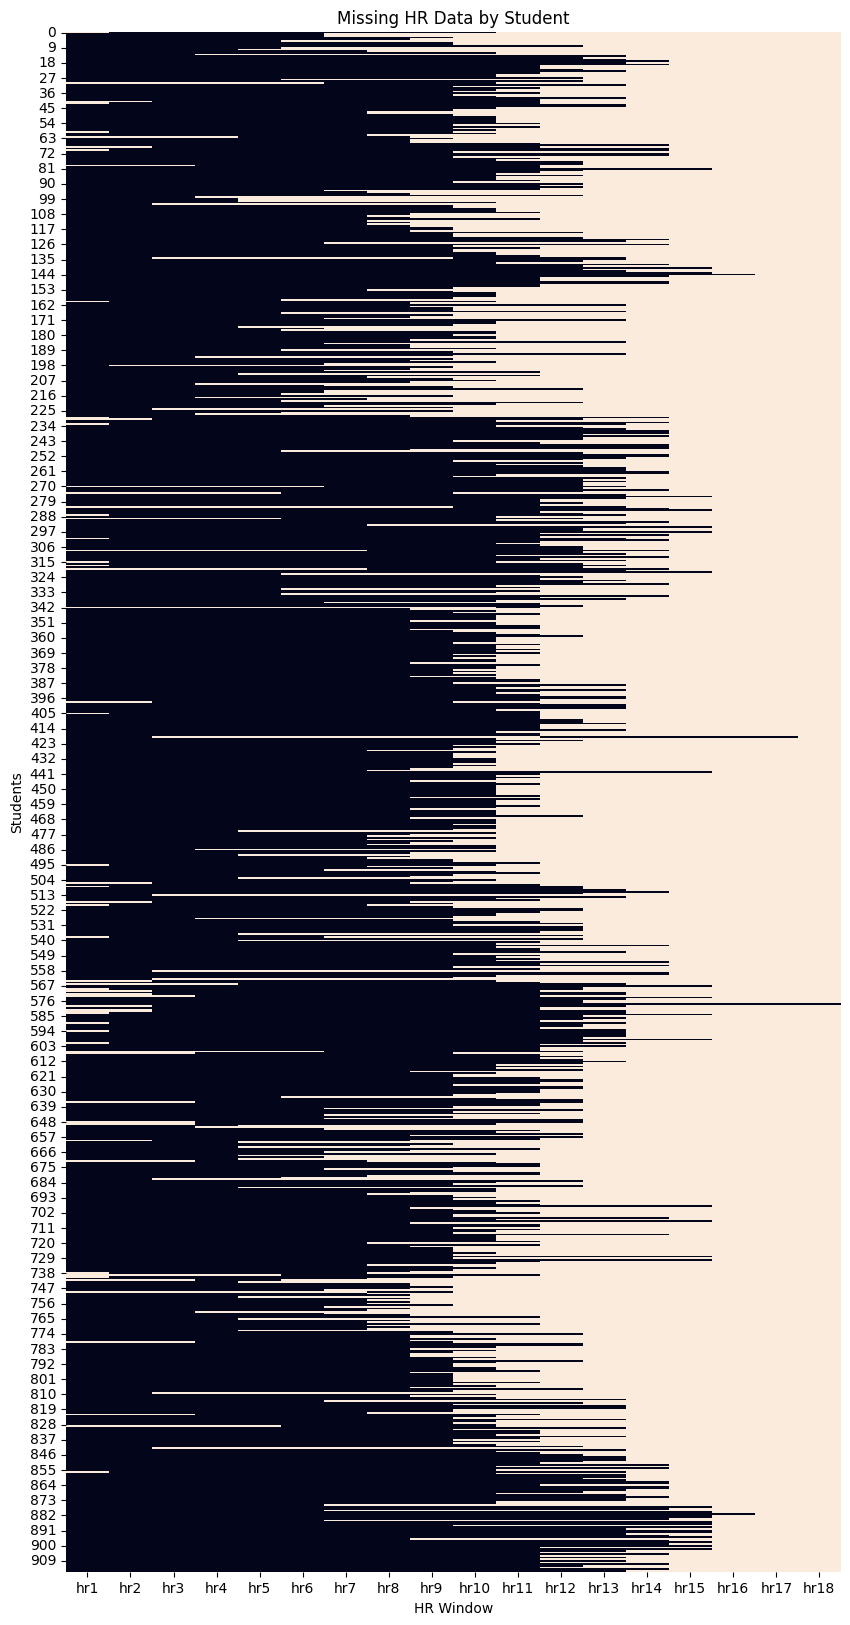

In [7]:
plt.figure(figsize=(10, 20))  # Width x Height in inches
sns.heatmap(df_physio[hr_cols].isna(), cbar=False)

plt.xlabel("HR Window")
plt.ylabel("Students")
plt.title("Missing HR Data by Student")
plt.show()

# plot shows that even student data is not stable across sessions and duration

In [8]:


# Identify all HR columns: hr1, hr2, ..., hr19
hr_columns = [col for col in df_physio.columns if col.lower().startswith("hr") and col[2:].isdigit()]

# Identify all SD columns: sd1, sd2, ..., sd19
sd_columns = [col for col in df_physio.columns if col.lower().startswith("sd") and col[2:].isdigit()]

# Create presence indicators by counting non-null values across the selected columns
df_physio["hr_presence"] = df_physio[hr_columns].notnull().sum(axis=1)
df_physio["sd_presence"] = df_physio[sd_columns].notnull().sum(axis=1)

df_physio.head()




,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,hr16,sd16,seg17,hr17,sd17,seg18,hr18,sd18,hr_presence,sd_presence
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,NaN,NaN,,NaN,NaN,,NaN,NaN,9,9
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,NaN,NaN,,NaN,NaN,,NaN,NaN,6,6
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,NaN,NaN,,NaN,NaN,,NaN,NaN,6,6
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,NaN,NaN,,NaN,NaN,,NaN,NaN,9,9
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,NaN,NaN,,NaN,NaN,,NaN,NaN,8,8


In [9]:

# Keep only students who have at least one HR value recorded
#df_physio = df_physio[df_physio["hr_presence"] > 0].copy()
#df_physio.shape

In [10]:

# Create a presence matrix (True = non-null)
hr_presence = df_physio[hr_columns].notnull().astype(int)

# Add session column
hr_presence['session'] = df_physio['session']
print('Size=', hr_presence.shape)
hr_presence.head()





Size= (916, 19)


,hr1,hr2,hr3,hr4,hr5,hr6,hr7,hr8,hr9,hr10,hr11,hr12,hr13,hr14,hr15,hr16,hr17,hr18,session
0,0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,11
1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,20
2,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,20
3,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,18
4,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,10


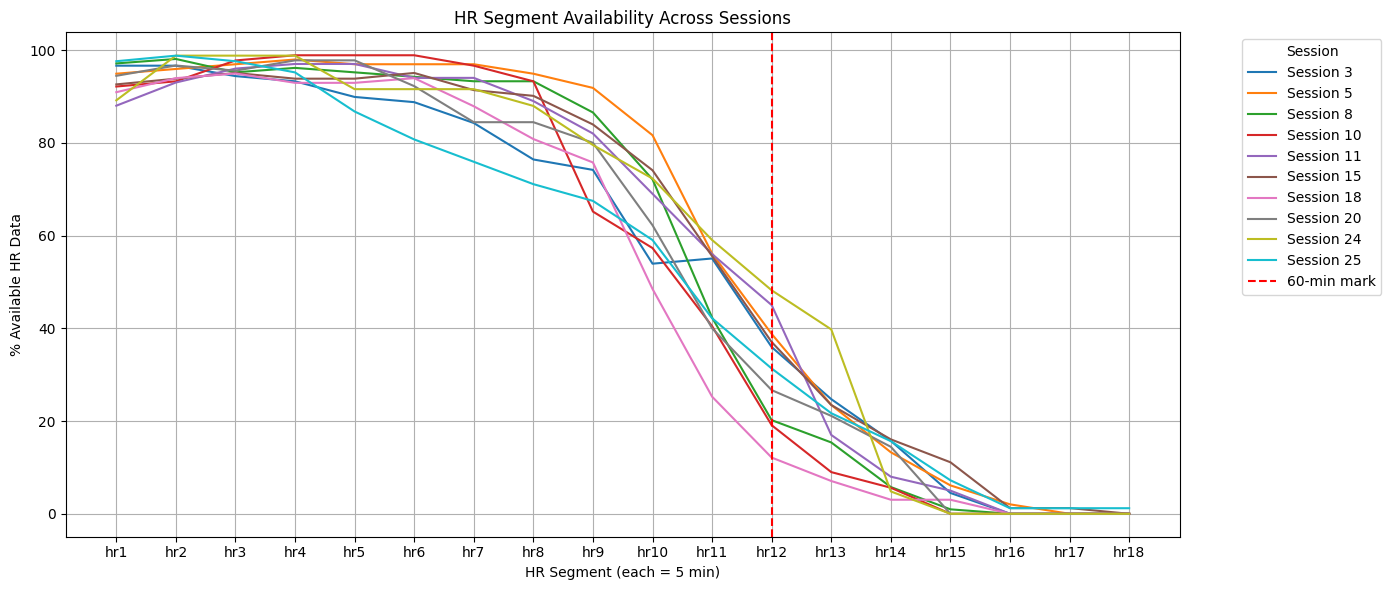

In [11]:
# Group by session and compute % of data available for each hr segment
session_hr_pct = hr_presence.groupby('session')[hr_columns].mean() * 100

# Plot as line plot to show longitudinal drop-offs
plt.figure(figsize=(14, 6))
for session in session_hr_pct.index:
    plt.plot(range(1, 19), session_hr_pct.loc[session], label=f'Session {session}')

plt.xlabel('HR Segment (each = 5 min)')
plt.ylabel('% Available HR Data')
plt.axvline(x=12, color='red', linestyle='--', label='60-min mark')
plt.title('HR Segment Availability Across Sessions')
plt.xticks(range(1, 19), [f'hr{i}' for i in range(1, 19)])
plt.legend(title='Session', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()




Text(0.5, 1.0, 'HR Segment Availability by Session')

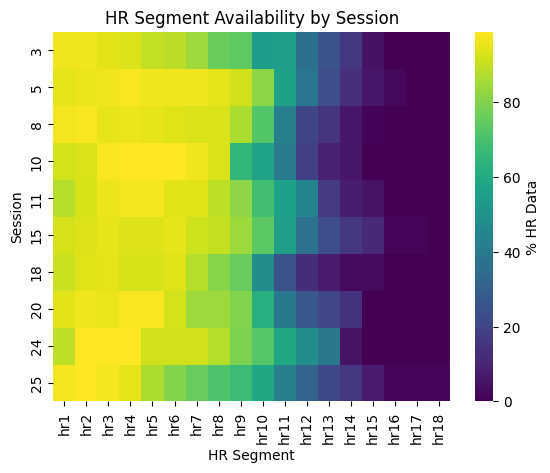

In [12]:
sns.heatmap(session_hr_pct, cmap='viridis', cbar_kws={'label': '% HR Data'})
plt.xlabel('HR Segment')
plt.ylabel('Session')
plt.title('HR Segment Availability by Session')

## Creating window size for analysis

it seems data availability reduces tremendously after 60 seconds 


In [13]:
# --- Goal --------------------------------------------------------------
# Create PRIMARY (landmark) and SECONDARY windows for HR analysis that:
#   1) respect unequal session lengths,
#   2) avoid late-session informative missingness,
#
# Strategy (pre-registered, model-agnostic):
#   • Compute per-session, per-segment (% available) coverage.
#   • Choose the LARGEST cut point t* (in minutes) such that:
#       median_session_coverage(t*) ≥ COV_MEDIAN_MIN   AND
#       lower_quartile_session_coverage(t*) ≥ COV_Q1_MIN
#     — this maximizes comparable data while limiting MNAR risk.
#   • Use segments ≤ t* for the PRIMARY (landmark) window.
#   • Keep segments > t* as SECONDARY (sensitivity / dynamic update).
#
# Notes:
#   • Segments are 5-min bins: hr1=5, hr2=10, …, hr19=95.
#   • SD columns (sd1..sd19) are kept to optionally form reliability weights.



# ----------------------------------------------------------------------
# METADATA: infer session column; set coverage thresholds
# ----------------------------------------------------------------------
import re

# Explicitly set the session column
SESSION_COL = "session"

# Coverage rules
COV_MEDIAN_MIN = 80.0   # median coverage ≥ 80%
COV_Q1_MIN     = 60.0   # lower quartile coverage ≥ 60%

# Helper: map hrN/sdN -> minutes
seg_to_minutes = lambda col: int(re.search(r"(\d+)$", col).group(1)) * 5

# Sort columns chronologically
hr_columns = sorted(hr_columns, key=seg_to_minutes)
sd_columns = sorted(sd_columns, key=seg_to_minutes)

print("Session column:", SESSION_COL)
print(hr_columns)
print(sd_columns)



Session column: session
['hr1', 'hr2', 'hr3', 'hr4', 'hr5', 'hr6', 'hr7', 'hr8', 'hr9', 'hr10', 'hr11', 'hr12', 'hr13', 'hr14', 'hr15', 'hr16', 'hr17', 'hr18']
['sd1', 'sd2', 'sd3', 'sd4', 'sd5', 'sd6', 'sd7', 'sd8', 'sd9', 'sd10', 'sd11', 'sd12', 'sd13', 'sd14', 'sd15', 'sd16', 'sd17', 'sd18']


In [14]:
# ----------------------------------------------------------------------
# COVERAGE: % available HR per session × segment, plus cross-session summary
# ----------------------------------------------------------------------
def compute_segment_coverage(df, group_col, seg_cols):
    """
    Returns:
      coverage_by_session: DataFrame [session × segment] with % non-null
      coverage_summary   : DataFrame [segment] with median, q1, q3 across sessions
    """
    # % available within each session at each segment
    coverage_by_session = (
        df.groupby(group_col)[seg_cols]
          .apply(lambda g: g.notnull().sum() / len(g) * 100.0)
          .sort_index()
    )
    # Cross-session distribution for each segment
    coverage_summary = pd.DataFrame({
        "median": coverage_by_session.median(axis=0),
        "q1"    : coverage_by_session.quantile(0.25, axis=0),
        "q3"    : coverage_by_session.quantile(0.75, axis=0),
    })
    coverage_summary["minutes"] = [seg_to_minutes(c) for c in coverage_summary.index]
    return coverage_by_session, coverage_summary.sort_values("minutes")

coverage_by_session, coverage_summary = compute_segment_coverage(
    df_physio, SESSION_COL, hr_columns
)


# The values are percentages of non-null entries for that segment in that session.
# Example = Session 3, hr1 = 96.63 → in session 3, 96.6% of values in hr1 were non-missing.
# sensors/recordings tend to be reliable at the start of the session but coverage decreases toward the end.
#  Session differences: Some sessions have much higher sustained coverage (e.g., session 5 stays strong until hr10 before dropping), while others lose coverage earlier (e.g., session 18 drops quickly after hr7).
print(coverage_by_session)


               hr1        hr2        hr3        hr4        hr5        hr6  \
session                                                                     
3        96.629213  96.629213  94.382022  93.258427  89.887640  88.764045   
5        94.897959  95.918367  96.938776  97.959184  96.938776  96.938776   
8        97.115385  98.076923  95.192308  96.153846  95.192308  94.230769   
10       92.134831  93.258427  97.752809  98.876404  98.876404  98.876404   
11       88.000000  93.000000  96.000000  97.000000  97.000000  94.000000   
15       92.592593  93.827160  95.061728  93.827160  93.827160  95.061728   
18       90.909091  93.939394  94.949495  92.929293  92.929293  93.939394   
20       94.444444  96.666667  95.555556  97.777778  97.777778  92.222222   
24       89.156627  98.795181  98.795181  98.795181  91.566265  91.566265   
25       97.590361  98.795181  97.590361  95.180723  86.746988  80.722892   

               hr7        hr8        hr9       hr10       hr11       hr12  

In [15]:
print(coverage_summary)

# segments are aggregated across all sessions.
# The median % coverage across all sessions for that segment.
# Example: hr1 = 93.5 → in the first 5 minutes, the typical session has about 93.5% HR data available.

# Strong coverage early (0–30 min).
# Gradual decline mid-session (30–60 min).
# Collapse after ~65 minutes (hr13 onward).


         median         q1         q3  minutes
hr1   93.518519  91.215526  96.196400        5
hr2   96.273790  93.855219  97.724359       10
hr3   95.777778  95.094373  97.427465       15
hr4   96.576923  94.165551  97.913832       20
hr5   94.509734  91.907022  96.984694       25
hr6   93.969697  91.730254  94.853989       30
hr7   91.462145  85.303030  93.817308       35
hr8   88.475904  81.717172  92.474684       40
hr9   79.759036  74.557371  83.462963       45
hr10  65.611111  57.736564  72.245714       50
hr11  48.681936  40.879247  55.888889       55
hr12  33.640179  21.810897  38.340892       60
hr13  21.398929  15.788462  23.466238       65
hr14  10.632653   5.655791  15.358099       70
hr15   3.762343   0.240385   5.841837       75
hr16   0.000000   0.000000   0.903614       80
hr17   0.000000   0.000000   0.000000       85
hr18   0.000000   0.000000   0.000000       90


In [16]:
# ----------------------------------------------------------------------
# CUT POINT SELECTION (coverage rule)
# ----------------------------------------------------------------------

# Recall Coverage rules
#COV_MEDIAN_MIN = 80.0   # median coverage ≥ 80%
#COV_Q1_MIN     = 60.0   # lower quartile coverage ≥ 60%

# Median ≥ X% → ensures the typical session has at least X% data coverage at that segment.
# Q1 ≥ Y% → ensures that even the worst 25% of sessions are not too poor in coverage.

# Alternative would be 75/50 #
# → would likely push to hr9 (~45 min).

# I assume this data is sensitive to missingness, better to be stay in conservative side


# Find all segments that satisfy the coverage thresholds, then pick the LARGEST (latest) one.

# Two rules
# COV_MEDIAN_MIN = 80% → The median coverage across sessions must be ≥80%.
# Inclusivity (longer time window, more sessions kept)

# COV_Q1_MIN = 60% → The lower quartile (25th percentile) coverage must be ≥60%.
# Data quality (less missingness, less imputation bias).
eligible = coverage_summary[
    (coverage_summary["median"] >= COV_MEDIAN_MIN) &
    (coverage_summary["q1"]    >= COV_Q1_MIN)
]

if len(eligible) > 0:
    t_star_minutes = int(eligible["minutes"].max())
    t_star_segment = [c for c in hr_columns if seg_to_minutes(c) == t_star_minutes][0]
else:
    # Fallback (pre-specified) to 60 minutes if coverage rule finds none.
    t_star_minutes = 60
    # Find nearest existing segment ≤ 60 (e.g., hr12). If none, use the earliest available.
    candidates = [c for c in hr_columns if seg_to_minutes(c) <= t_star_minutes]
    t_star_segment = candidates[-1] if candidates else hr_columns[0]

print(f"[Window selection] PRIMARY landmark cut point t* = {t_star_minutes} min (segment: {t_star_segment}).")
print(coverage_summary.loc[[t_star_segment]])

# Interpretation for 80/60
# hr8 (40 min) → median = 88.5%, q1 = 81.7%  meets both thresholds.
# hr9 (45 min) → median = 79.8% fails the median ≥80% rule.
# hr10 (50 min) → median = 65.6%, q1 = 57.7%  fails both rules.


[Window selection] PRIMARY landmark cut point t* = 40 min (segment: hr8).
        median         q1         q3  minutes
hr8  88.475904  81.717172  92.474684       40


In [17]:

# ----------------------------------------------------------------------
# DEFINE PRIMARY & SECONDARY WINDOWS
# ----------------------------------------------------------------------
primary_hr_cols   = [c for c in hr_columns if seg_to_minutes(c) <= t_star_minutes]
secondary_hr_cols = [c for c in hr_columns if seg_to_minutes(c) >  t_star_minutes]

primary_sd_cols   = [c.replace("hr","sd") for c in primary_hr_cols if c.replace("hr","sd") in sd_columns]
secondary_sd_cols = [c.replace("hr","sd") for c in secondary_hr_cols if c.replace("hr","sd") in sd_columns]

analysis_windows = {
    "primary": {
        "minutes": (0, t_star_minutes),
        "hr_cols": primary_hr_cols,
        "sd_cols": primary_sd_cols
    },
    "secondary": {
        "minutes": (t_star_minutes + 5, seg_to_minutes(hr_columns[-1])),
        "hr_cols": secondary_hr_cols,
        "sd_cols": secondary_sd_cols
    }
}

print("\n[Window columns]")
for name, cfg in analysis_windows.items():
    print(f"  • {name.upper():<9} {cfg['minutes'][0]:>2d}–{cfg['minutes'][1]:>3d} min | "
          f"{len(cfg['hr_cols'])} HR segs | {len(cfg['sd_cols'])} SD segs")



[Window columns]
  • PRIMARY    0– 40 min | 8 HR segs | 8 SD segs
  • SECONDARY 45– 90 min | 10 HR segs | 10 SD segs


In [18]:

# ----------------------------------------------------------------------
# Build reliability weights from SDs (for downstream sensitivity)
# ----------------------------------------------------------------------
def build_inverse_variance_weights(df, sd_cols, eps=1e-6, normalize="row"):
    """
    Create weights w_j = 1 / (sd_j^2 + eps).
    Rationale: segments with larger within-bin variability contribute less.
    Use ONLY in sensitivity analyses; the primary DTM fit can remain unweighted.

    normalize='row'  : scale weights so they sum to 1 within each row (student-session)
    normalize=None   : leave as raw inverse-variance weights
    """
    if not sd_cols:
        return pd.DataFrame(index=df.index)
    w = 1.0 / (df[sd_cols] ** 2 + eps)
    if normalize == "row":
        w = w.div(w.sum(axis=1), axis=0).fillna(0.0)
    return w.add_prefix("w_")  # columns like w_sd1, w_sd2, ...

# Weights aligned to PRIMARY window (used later in sensitivity runs)
w_primary = build_inverse_variance_weights(df_physio, primary_sd_cols, normalize="row")
w_primary 



,w_sd1,w_sd2,w_sd3,w_sd4,w_sd5,w_sd6,w_sd7,w_sd8
0,0.000000,0.138477,0.064805,0.114760,0.105893,0.155016,0.237064,0.183984
1,0.232932,0.124938,0.121593,0.180559,0.140616,0.199364,0.000000,0.000000
2,0.157589,0.218336,0.200815,0.149924,0.126625,0.146710,0.000000,0.000000
3,0.110860,0.087199,0.115920,0.109555,0.113926,0.118030,0.236434,0.108076
4,0.142068,0.115973,0.110229,0.112945,0.128833,0.111577,0.123769,0.154606
...,...,...,...,...,...,...,...,...
911,0.071290,0.098352,0.196317,0.104358,0.097977,0.136742,0.149631,0.145333
912,0.065588,0.075839,0.094757,0.323919,0.102268,0.104911,0.122861,0.109857
913,0.102855,0.109833,0.091587,0.166422,0.143170,0.118825,0.109350,0.157959
914,0.128554,0.091236,0.114651,0.137040,0.108312,0.135242,0.133629,0.151336


In [19]:

# ----------------------------------------------------------------------
#  OUTPUT OBJECTS for modeling stages
# ----------------------------------------------------------------------
# • coverage_by_session  : % availability per session × segment (for your QC plots)
# • coverage_summary     : cross-session median/q1/q3 by segment (audit the cut point)
# • analysis_windows     : dict holding PRIMARY/SECONDARY minute ranges + columns
# • w_primary            : optional inverse-variance weights for PRIMARY window

# Example usage in later steps:
#   X_primary  = df_physio[primary_hr_cols]
#   X_secondary= df_physio[secondary_hr_cols]
#   W_primary  = w_primary  # pass as sample weights in sensitivity analyses

# For reproducibility in the paper, freeze the chosen t*:
PRIMARY_CUT_MINUTES = t_star_minutes  # << record this in your preregistration
 

#### Summary

**Cut-point chosen (coverage rule):**
-  Using the pre-specified thresholds (median ≥80%, Q1 ≥60% across sessions), the **last segment that satisfies both is hr8 = 40 minutes**. 
-  At 45 minutes (hr9) the median drops to **79.8%** and continues to fall steeply (50 min median **65.6%**, 60 min median **33.6%**), so ≥45 min fails the rule. 
-  **Primary window = 0–40 min (hr1–hr8)**; **Secondary window = 45–90 min (hr9–hr18).** 

**Rationale check:** 
- The 0–40 min window retains **high, stable coverage** (medians \~88–96%, Q1s \~82–95%) and avoids the heavy late-session attrition visible from 50–60 min onward.  
- This supports our *early-identification* goal and limits MNAR bias in the unsupervised embedding step. 

**Weights (optional sensitivity):** 
- We constructed **row-normalized inverse-variance weights for sd1–sd8** (one row per student-session). 
- Rows sum to \~1; zeros indicate missing SDs for those segments. These can be used in sensitivity analyses to down-weight noisier intervals during association testing or weighted fits.  




# FIT DTM

**Next steps:**

  1. Fit DTM (or comparator FPCA/RR-LMM) on **hr1–hr8** to learn embeddings and cluster students.
  2. Freeze this 0–40 min choice in the prereg plan; run **sensitivity** at 45 and 60 min and with **all minutes** to report stability/concordance.
  3. Use the secondary window for **dynamic updates** (e.g., re-embed at 45/60 min) and for robustness checks.

In [20]:

# =================================================================================================
# DTM WORKFLOW — PRIMARY WINDOW (0–t*) with a plug-in “DTM-lite” embedding for now.
#
# Why this structure?
#   •  this code uses a statistically principled surrogate that is faithful to
#     the DTM idea: learn a low-dimensional embedding of short, irregular time series and then
#     cluster the embeddings. The surrogate is:
#         (smoothing / imputation) + probabilistic PCA-style embedding + GMM clustering
#     with rigorous masking for missing segments and frozen preprocessing so we can project
#     partial sessions later (early-warning).
#
# Inputs expected from previous steps:
#   • df_physio            : long table with one row per student×session; columns hr1..hr18, sd1..sd18
#   • analysis_windows     : dict with 'primary'/'secondary' -> {'hr_cols', 'sd_cols', 'minutes'}
#   • PRIMARY_CUT_MINUTES  : chosen landmark cut point in minutes (e.g., 40)
#   • (Optional) w_primary : row-normalized weights for sd1..sdK (used in sensitivity, not in the
#                            base fit here; keep for later robustness checks).
#
# Outputs created here:
#   • DTMModel object with .fit(), .transform(), .fit_transform(), .project_partial()
#   • df_embed: DataFrame with embedding coordinates (z1,z2,...) and cluster labels
#   • gmm_model: fitted GaussianMixture for downstream responsibilities / early warning
#
# Reproducibility: set RNG_SEED and keep it fixed for your preregistration.
# =================================================================================================



RNG_SEED = 17

#  Grab the PRIMARY window columns -----------------------------------------------------------
primary_hr_cols = analysis_windows["primary"]["hr_cols"]
assert len(primary_hr_cols) > 0, "PRIMARY window not defined. Run the window-selection block first."
T = len(primary_hr_cols)

# Helper: segment name -> minutes
def seg_to_minutes(colname: str) -> int:
    return int(re.search(r"(\d+)$", colname).group(1)) * 5

# Time grid (in minutes) for reference / later visualization
t_minutes = np.array([seg_to_minutes(c) for c in primary_hr_cols])

#  Build the modeling matrix with explicit masking -------------------------------------------
# X_raw: shape [N × T]; 
# Rows = sessions (student × session) → each observation.
# Columns = HR segments within the primary window (hr1–hr8).
X_raw = df_physio[primary_hr_cols].copy()
print(X_raw.head())


         hr1         hr2         hr3        hr4        hr5         hr6  \
0        NaN  105.086292   96.611561  98.060078  95.428328   95.856966   
1  90.058329   90.664877   92.077894  89.656606  88.670404   92.682969   
2  87.944465   82.641167   87.277188  88.251017  94.818559  106.760380   
3  82.176543   85.620156   81.076241  85.781230  79.511457   80.976700   
4  95.597462  103.381791  100.369257  90.633295  94.603969   96.084468   

         hr7         hr8  
0  99.005781  100.217482  
1        NaN         NaN  
2        NaN         NaN  
3  72.433403   82.117978  
4  95.835813   98.304690  


In [21]:
# a boolean mask of the same shape, where True = observed (not missing), False = missing (NaN).
M = ~X_raw.isna().values
M


array([[False,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True, False, False],
       [ True,  True,  True, ...,  True, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [22]:
# the number of observations (rows in df_physio).
N = X_raw.shape[0]
print('Length=', N)


Length= 916


## Version I


### What matches the paper’s intent

* **Low-dimensional embedding of trajectories** for visualization/clustering and outcome analysis ↔ the paper’s central objective.
* **Handling missingness** before embedding (you use explicit masks + imputation; the paper models irregular sampling natively via subject-specific design matrices $B_i$).&#x20;
* **Projecting partial trajectories** (your `project_partial`) ↔ the paper’s ability to infer/posterior-predict from partial histories.&#x20;

### Where it diverges from the DTM methodology (the important bits)

1. **Model class**

* Yours: deterministic pipeline = IterativeImputer (BayesianRidge) → per-timepoint standardization → **PCA**.
* Paper: **generative model** derived from reduced-rank LMM; marginalize basis weights to obtain a **GP over trajectories/coefficients** with a **kernel in the latent space $x_i$**; learn with **stochastic variational inference** and **inducing points**; keep **posterior uncertainty** over $x_i$ and GP parameters.&#x20;

2. **Basis / time handling**

* Yours: fixed, equally-spaced bins (hr1…hr8) after coverage gating; impute onto that grid.
* Paper: each subject has a **design matrix $B_i$** (e.g., B-splines) evaluated at that subject’s **actual observation times**, so **irregular sampling is native** (no pre-imputation grid needed).&#x20;

3. **Uncertainty & inference**

* Yours: single point embedding (no posterior over $x_i$); clustering uses a downstream GMM on PCA scores.
* Paper: maintains **variational posteriors** over $x_i$ and inducing variables; supports **posterior predictive** for new/partial trajectories and principled uncertainty in downstream tests.&#x20;

4. **Learning objective**

* Yours: unsupervised reconstruction variance (PCA) after imputation.
* Paper: maximizes a **variational ELBO** for the DTM likelihood with kernel hyperparameters, inducing inputs, etc. (scales via SVI).&#x20;

### Why this matters

* **Bias from imputation:** deterministic imputation + PCA can distort shapes, especially under nonrandom missingness.
* **Irregular timing:** binning loses information that $B_i$ preserves.
* **No uncertainty:** you can’t propagate embedding uncertainty into clustering or outcome association tests, which the paper explicitly does.&#x20;

In [23]:
# --- Imports you need somewhere once ------------------------------------------
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  <-- REQUIRED
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# --- DTM-lite model ------------------------------------------------------------
class DTMModel:
    """
    DTM-lite embedding:
      • IterativeImputer (BayesianRidge) to complete missing segments.
      • Column-standardize (per time bin) to emphasize shape over level.
      • PCA to obtain a low-dim latent space (q=2–3 typical).
      • Frozen preprocessing enables .project_partial().

    Notes:
      - Columns that are ALL NaN across rows are dropped at fit and remembered.
      - At transform/project_partial, those columns are ignored consistently.
    """
    def __init__(self, q=3, impute_max_iter=25, random_state=17):
        self.q = q
        self.imputer = IterativeImputer(
            max_iter=impute_max_iter, random_state=random_state, sample_posterior=False
        )
        self.scaler = StandardScaler(with_mean=True, with_std=True)
        self.pca = PCA(n_components=q, random_state=random_state)
        self._cols_keep = None       # columns actually used (non all-NaN at fit)
        self.fitted_ = False

    # ---- internals -------------------------------------------------------------
    def _select_fit_columns(self, X: pd.DataFrame):
        # drop columns that are entirely NaN across rows (IterativeImputer cannot learn them)
        all_nan = X.columns[X.isna().all(axis=0)]
        cols_keep = [c for c in X.columns if c not in set(all_nan)]
        if len(cols_keep) == 0:
            raise ValueError("All features are NaN; cannot fit DTMModel.")
        return cols_keep

    def _align_and_subset(self, X: pd.DataFrame):
        # ensure the input has at least the training columns in the same order
        missing = [c for c in self._cols_keep if c not in X.columns]
        if missing:
            raise ValueError(f"Input is missing columns seen at fit: {missing}")
        Xs = X[self._cols_keep].copy()
        return Xs

    # ---- API -------------------------------------------------------------------
    def fit(self, X: pd.DataFrame):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        self._cols_keep = self._select_fit_columns(X)
        X_fit = X[self._cols_keep].copy()

        # 1) learn imputer, complete the matrix
        X_imp = self.imputer.fit_transform(X_fit)

        # 2) per-timepoint z-scoring
        X_z = self.scaler.fit_transform(X_imp)

        # 3) PCA on standardized data
        self.pca.fit(X_z)

        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        assert self.fitted_, "Call .fit() first."
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        Xs = self._align_and_subset(X)

        # impute with frozen imputer
        X_imp = self.imputer.transform(Xs)

        # standardize with frozen scaler
        X_z = self.scaler.transform(X_imp)

        # project to latent space
        Z = self.pca.transform(X_z)
        return Z

    def fit_transform(self, X: pd.DataFrame):
        self.fit(X)
        return self.transform(X)

    def project_partial(self, X_partial: pd.DataFrame):
        """
        Project partial trajectories (some segments missing). Uses the same
        imputer + scaler + PCA learned in fit().
        """
        return self.transform(X_partial)


### Version II

- What it does (closer to the paper’s spirit):

- Projects each row’s time series onto a smooth basis (default: cubic polynomial basis; optional: B-splines if patsy is installed).

- Estimates ridge-regularized coefficients per row with masking (no pre-impute to a grid).

- Standardizes coefficients across subjects.

- Uses Factor Analysis (probabilistic) for a low-dim embedding (instead of PCA), giving you a likelihood-based latent model.

In [24]:
import numpy as np
import pandas as pd
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# Optional: B-splines via patsy (if available). Falls back to cubic polynomials otherwise.
try:
    from patsy import dmatrix as _dmatrix
    _HAS_PATSY = True
except Exception:
    _HAS_PATSY = False


class DTMModel_FPCA:
    """
    DTM-like (functional baseline):
      1) Build a smooth basis B(t) over your primary window times.
      2) For each row i, solve masked ridge:  beta_i = argmin ||W_i (y_i - B beta)||^2 + alpha||beta||^2
         where W_i masks missing segments.
      3) Standardize coefficients across rows; embed with FactorAnalysis (probabilistic).
      4) project_partial() recomputes coefficients from the available segments using the *same* basis & ridge.
    """
    def __init__(self, q=3, basis="auto", n_basis=5, ridge_alpha=1.0, random_state=17):
        """
        q          : latent dim
        basis     : 'auto' -> use 'bspline' if patsy present else 'poly'
                     'bspline' or 'poly' explicitly set
        n_basis   : #basis functions (df for splines; degree+1 for poly is fixed to 4 for cubic)
        ridge_alpha: ridge penalty for coefficient stability
        """
        self.q = q
        self.ridge_alpha = ridge_alpha
        self.random_state = random_state
        self.n_basis = n_basis
        self.basis = ("bspline" if (_HAS_PATSY and basis == "auto") else
                      ("poly" if basis == "auto" else basis))
        # learned/frozen params
        self._B = None           # [T × K] basis at training grid
        self._BtWB = None        # cached normal matrix per unique mask size (built on the fly)
        self._scaler = StandardScaler(with_mean=True, with_std=True)
        self._fa = FactorAnalysis(n_components=q, random_state=random_state)
        self._t_grid = None
        self.fitted_ = False

    # ---- helpers -----------------------------------------------------------------
    @staticmethod
    def _safe_minmax(x):
        x = np.asarray(x, float)
        lo, hi = np.nanmin(x), np.nanmax(x)
        if hi <= lo:  # degenerate
            return np.zeros_like(x)
        return (x - lo) / (hi - lo)

    def _build_basis(self, t_minutes):
        """
        Return B [T×K] evaluated at provided t grid.
        If 'poly': cubic polynomial [1, t, t^2, t^3] with t scaled to [0,1].
        If 'bspline': cubic B-splines with n_basis df (no intercept).
        """
        t_scaled = self._safe_minmax(t_minutes).reshape(-1, 1)  # [T×1] in [0,1]
        T = t_scaled.shape[0]
        if self.basis == "poly":
            # cubic polynomial basis (K=4), smooth surrogate if you can’t rely on patsy/scipy
            B = np.concatenate([np.ones((T, 1)),
                                t_scaled,
                                t_scaled**2,
                                t_scaled**3], axis=1)  # [T×4]
            return B
        else:
            # bspline via patsy
            # K = n_basis, degree=3, exclude intercept
            # NOTE: t_scaled.flatten() goes to 'x' in the dmatrix
            B = _dmatrix("bs(x, df=%d, degree=3, include_intercept=False)" % self.n_basis,
                         {"x": t_scaled.flatten()}, return_type="dataframe").to_numpy()
            return np.asarray(B, float)

    def _masked_ridge_solve(self, y, B, alpha):
        """
        Solve (B^T W B + alpha I) beta = B^T W y,
        where W is diagonal with 1 for observed entries, 0 for NaNs.
        """
        y = np.asarray(y, float)
        mask = ~np.isnan(y)
        if mask.sum() == 0:
            # no data → return zeros
            return np.zeros(B.shape[1], dtype=float)
        Bo = B[mask, :]                    # observed rows only
        yo = y[mask]
        # normal equations
        BtB = Bo.T @ Bo
        BtY = Bo.T @ yo
        K = BtB.shape[0]
        beta = np.linalg.solve(BtB + alpha * np.eye(K), BtY)
        return beta

    # ---- API ---------------------------------------------------------------------
    def fit(self, X: pd.DataFrame, t_minutes=None):
        """
        X: [N×T] DataFrame with NaNs allowed.
        t_minutes: optional array-like of length T; if None, infer from columns like 'hr8' → 40.
        """
        if t_minutes is None:
            # infer minutes from column names ending with 1..18, each bin = 5 min
            import re
            def seg_to_minutes(col):
                m = re.search(r"(\d+)$", col)
                return int(m.group(1)) * 5 if m else None
            t_minutes = np.array([seg_to_minutes(c) for c in X.columns], dtype=float)

        self._t_grid = np.asarray(t_minutes, float)
        self._B = self._build_basis(self._t_grid)   # [T×K]
        K = self._B.shape[1]

        # coefficient matrix [N×K]
        coefs = np.zeros((X.shape[0], K), dtype=float)
        for i, (_, row) in enumerate(X.iterrows()):
            coefs[i, :] = self._masked_ridge_solve(row.values, self._B, self.ridge_alpha)

        # standardize across subjects
        coefs_z = self._scaler.fit_transform(coefs)

        # probabilistic embedding
        self._fa.fit(coefs_z)
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        assert self.fitted_, "Call .fit() first."
        # compute coefficients with the *same* basis, same ridge
        coefs = np.vstack([self._masked_ridge_solve(row.values, self._B, self.ridge_alpha)
                           for _, row in X.iterrows()])
        coefs_z = self._scaler.transform(coefs)
        Z = self._fa.transform(coefs_z)  # [N×q]
        return Z

    def fit_transform(self, X: pd.DataFrame):
        self.fit(X)
        return self.transform(X)

    def project_partial(self, X_partial: pd.DataFrame):
        # identical to transform(): masked ridge + scaler + FA
        return self.transform(X_partial)


## Version III

**What it does (another principled surrogate):**

- Implements EM-PCA for data with NaNs:

- Initialize missing entries with column means.

- Alternate: (E) fill NaNs with current low-rank reconstruction; (M) refit PCA on the completed matrix.

- No separate imputer; mask is honored during reconstruction.

- Standardizes per time bin (shape emphasis), like your current model.

- Returns scores as the embedding; project_partial() runs EM steps only for the rows you pass using the learned loadings (fast “fold-in”).


We turn each student’s minute-by-minute heart-rate curve into three numbers that capture its overall shape.

Because some minutes are missing, we use an iterative fill-and-refit approach: we fit a compact “shape model” to the parts we see, use it to predict the missing minutes, refit, and repeat until things stop changing.

Once that “shape model” is learned, we can take a partially observed new session (say the first 10–30 minutes), and place it onto the same map using only the minutes we’ve seen. 

These three numbers (the embedding) are then used to cluster sessions and to predict early on whether a student is likely to be non-responsive to the intervention.

In [25]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

class DTMModel_EMPCA:
    """
    EM-PCA with missing data:
      - Keeps masking; no external imputer.
      - Column standardization (shape over level).
      - Low-rank reconstruction iterates until convergence; embeddings are PCA scores.
      - project_partial() fold-in with fixed loadings.
    """
    def __init__(self, q=3, max_em_iters=50, tol=1e-5, random_state=17):
        self.q = q
        self.max_em_iters = max_em_iters
        self.tol = tol
        self.random_state = random_state
        self._scaler = StandardScaler(with_mean=True, with_std=True)
        self._pca = PCA(n_components=q, random_state=random_state)
        self._loadings = None  # [T×q]
        self._col_means = None
        self.fitted_ = False

    def _complete_with_means(self, X):
        Xc = X.copy()
        # fill NaNs with column means
        for j in range(Xc.shape[1]):
            col = Xc[:, j]
            m = np.nanmean(col)
            col[np.isnan(col)] = m
            Xc[:, j] = col
        return Xc

    def fit(self, X: pd.DataFrame):
        Xv = X.values.astype(float)
        mask = ~np.isnan(Xv)

        # init: fill with column means
        X_complete = self._complete_with_means(Xv)
        # standardize per time bin
        Xz = self._scaler.fit_transform(X_complete)

        prev_obj = None
        for it in range(self.max_em_iters):
            # M-step: fit PCA loadings/scores on completed, standardized data
            self._pca.fit(Xz)
            L = self._pca.components_.T    # [T×q]
            S = self._pca.transform(Xz)    # [N×q]
            Xhat = S @ L.T                 # reconstruction in z-space

            # E-step: put back observed values; update missing with reconstruction
            Xz_new = Xz.copy()
            # For observed entries, enforce original standardized values
            Xz_new[mask] = Xz[mask]
            # For missing entries, replace with reconstruction
            Xz_new[~mask] = Xhat[~mask]

            # Check convergence via change in reconstruction on missing entries
            diff = np.linalg.norm((Xz_new - Xz)[~mask]) / (np.sqrt((~mask).sum()) + 1e-9)
            Xz = Xz_new
            if diff < self.tol:
                break

        # Final fit on the converged completed data
        self._pca.fit(Xz)
        self._loadings = self._pca.components_.T  # [T×q]
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame):
        assert self.fitted_, "Call .fit() first."
        Xv = X.values.astype(float)
        mask = ~np.isnan(Xv)

        # Standardize with training scaler, keeping NaNs
        X_center = (Xv - self._scaler.mean_) / (self._scaler.scale_ + 1e-9)

        # One-step fold-in EM for rows: initialize missing with 0 in z-space (mean), then solve for scores
        # Given loadings L, scores s minimize || P_mask( Xz - s L^T ) ||^2 → closed-form per row
        L = self._loadings  # [T×q]
        Z = np.zeros((Xv.shape[0], self.q), dtype=float)

        for i in range(Xv.shape[0]):
            mi = mask[i, :]
            if mi.sum() == 0:
                Z[i, :] = 0.0
                continue
            Li = L[mi, :]                  # [Ti×q]
            xi = X_center[i, mi]           # [Ti]
            # normal equations: (Li^T Li) s = Li^T xi
            A = Li.T @ Li + 1e-6 * np.eye(self.q)
            b = Li.T @ xi
            Z[i, :] = np.linalg.solve(A, b)

        return Z

    def fit_transform(self, X: pd.DataFrame):
        self.fit(X)
        return self.transform(X)

    def project_partial(self, X_partial: pd.DataFrame):
        # same as transform(): fold-in using fixed loadings and training scaler
        return self.transform(X_partial)


### Run the Models

In [26]:
#  Helper function to Choose #clusters via BIC (and report silhouette as a descriptive check) -------------------
def choose_gmm_k(Z, k_min=2, k_max=6, random_state=RNG_SEED):
    best = None
    rows = []
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              reg_covar=1e-6, random_state=random_state, n_init=5)
        gmm.fit(Z)
        bic = gmm.bic(Z)
        try:
            sil = silhouette_score(Z, gmm.predict(Z))
        except Exception:
            sil = np.nan
        rows.append({"k": k, "bic": bic, "silhouette": sil})
        if best is None or bic < best["bic"]:
            best = {"k": k, "model": gmm, "bic": bic, "silhouette": sil}
    return best, pd.DataFrame(rows).sort_values("k")



In [27]:
def package_results(Z, resp, labels, k_star, df_index, model_tag, q_latent, primary_minutes):
    emb_cols = [f"emb_{model_tag}{i+1}" for i in range(q_latent)]
    df_embed = pd.DataFrame(Z, columns=emb_cols, index=df_index)
    for j in range(k_star):
        df_embed[f"p_cluster_{model_tag}{j+1}"] = resp[:, j]
    df_embed[f"cluster_{model_tag}"] = labels + 1          # 1..K
    df_embed[f"cluster_k_{model_tag}"] = k_star
    df_embed[f"primary_minutes_{model_tag}"] = primary_minutes
    return df_embed


In [28]:
def run_model_variant(model, X_raw, df_physio, model_tag, q_latent,
                      k_min=2, k_max=6, random_state=17, save=True):
    """Fits model → picks K via BIC → prints QC → packages & (optionally) saves."""
    import numpy as np

    # --- fit + embed
    Z = model.fit_transform(X_raw)

    # --- choose K
    best, grid = choose_gmm_k(Z, k_min=k_min, k_max=k_max, random_state=random_state)
    gmm = best["model"]
    k_star = best["k"]
    sil = best.get("silhouette", np.nan)

    # --- responsibilities + labels
    resp = gmm.predict_proba(Z)
    labels = gmm.predict(Z)

    # --- package
    df_embed = package_results(
        Z=Z, resp=resp, labels=labels, k_star=k_star,
        df_index=df_physio.index, model_tag=model_tag,
        q_latent=q_latent, primary_minutes=PRIMARY_CUT_MINUTES
    )

    # --- merge (unique column names prevent collisions)
    df_physio_out = pd.concat([df_physio, df_embed], axis=1)

    # --- prints (mirrors your previous style)
    print(f"[{model_tag}] Primary window: 0–{PRIMARY_CUT_MINUTES} min across {T} segments "
          f"({primary_hr_cols[0]}..{primary_hr_cols[-1]}).")
    if np.isnan(sil):
        sil_msg = "NA"
    else:
        sil_msg = f"{sil:.3f}"
    print(f"[{model_tag}] Latent dim q = {q_latent}.  Selected clusters K = {k_star}.  Silhouette(K*) = {sil_msg}")
    print(f"[{model_tag}] GMM model-selection grid (lower BIC is better):")
    print(grid)

    # cluster sizes (nice for quick sanity check)
    counts = pd.Series(labels + 1).value_counts().sort_index()
    print(f"[{model_tag}] Cluster counts (1..K):")
    print(counts.to_string())

    # --- save (optional)
    if save:
        df_embed.to_csv(f"embed_{model_tag}.csv", index=True)
        grid.to_csv(f"gmm_grid_{model_tag}.csv", index=False)
        print(f"[{model_tag}] Saved: embed_{model_tag}.csv, gmm_grid_{model_tag}.csv")

    # Return everything you might want later
    return {
        "Z": Z, "gmm": gmm, "grid": grid, "k_star": k_star,
        "resp": resp, "labels": labels, "df_embed": df_embed
    }, df_physio_out


In [29]:
# DTM-lite
q_latent = 3
dtm = DTMModel(q=q_latent, impute_max_iter=25, random_state=RNG_SEED)
dtm_artifacts, df_physio = run_model_variant(
    model=dtm,
    X_raw=X_raw,
    df_physio=df_physio,
    model_tag="DTM",
    q_latent=q_latent,
    k_min=2, k_max=6,
    random_state=RNG_SEED,
    save=True
)

[DTM] Primary window: 0–40 min across 8 segments (hr1..hr8).
[DTM] Latent dim q = 3.  Selected clusters K = 2.  Silhouette(K*) = 0.218
[DTM] GMM model-selection grid (lower BIC is better):
   k          bic  silhouette
0  2  8303.423117    0.218209
1  3  8325.354111    0.226662
2  4  8390.584402    0.214629
3  5  8448.400406    0.179420
4  6  8506.362223    0.171677
[DTM] Cluster counts (1..K):
1    743
2    173
[DTM] Saved: embed_DTM.csv, gmm_grid_DTM.csv


In [30]:
df_physio.head()

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,hr_presence,sd_presence,emb_DTM1,emb_DTM2,emb_DTM3,p_cluster_DTM1,p_cluster_DTM2,cluster_DTM,cluster_k_DTM,primary_minutes_DTM
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,9,9,3.307292,-0.599638,0.941812,0.732329,0.267671,1,2,40
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,6,6,-0.487580,0.089852,0.084901,0.919023,0.080977,1,2,40
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,6,6,0.381409,2.690651,-0.526488,0.012489,0.987511,2,2,40
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,9,9,-5.111072,-1.036577,-0.548232,0.151812,0.848188,2,2,40
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,8,8,2.383122,-0.556944,0.789390,0.826893,0.173107,1,2,40


In [31]:
# EMPCA
q_latent = 3
dtm_EMPCA = DTMModel_EMPCA(q=q_latent, max_em_iters=50, tol=1e-5, random_state=RNG_SEED)
empca_artifacts, df_physio = run_model_variant(
    model=dtm_EMPCA,
    X_raw=X_raw,
    df_physio=df_physio,
    model_tag="EMPCA",
    q_latent=q_latent,
    k_min=2, k_max=6,
    random_state=RNG_SEED,
    save=True
)




[EMPCA] Primary window: 0–40 min across 8 segments (hr1..hr8).
[EMPCA] Latent dim q = 3.  Selected clusters K = 3.  Silhouette(K*) = 0.416
[EMPCA] GMM model-selection grid (lower BIC is better):
   k          bic  silhouette
0  2  9529.063781    0.511005
1  3  9494.117250    0.415883
2  4  9506.644406    0.202737
3  5  9532.275753    0.085447
4  6  9588.894079    0.249101
[EMPCA] Cluster counts (1..K):
1    822
2     41
3     53
[EMPCA] Saved: embed_EMPCA.csv, gmm_grid_EMPCA.csv


In [32]:
df_physio.head()

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,primary_minutes_DTM,emb_EMPCA1,emb_EMPCA2,emb_EMPCA3,p_cluster_EMPCA1,p_cluster_EMPCA2,p_cluster_EMPCA3,cluster_EMPCA,cluster_k_EMPCA,primary_minutes_EMPCA
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,40,3.692645,-0.625085,1.670199,8.642374e-01,0.133507,0.002256,1,3,40
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,40,-0.380964,0.284046,0.076266,9.897138e-01,0.004123,0.006163,1,3,40
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,40,3.457235,7.188218,0.584525,2.366720e-17,0.000100,0.999900,3,3,40
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,40,-5.190688,-1.046592,-0.167944,9.529869e-01,0.015664,0.031349,1,3,40
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,40,2.437466,-0.319796,0.866216,9.865348e-01,0.010251,0.003214,1,3,40


In [33]:
# FPCA (optional second run)
dtm_FPCA = DTMModel_FPCA(q=q_latent, basis="auto", n_basis=6, ridge_alpha=1.0, random_state=RNG_SEED)
fpca_artifacts, df_physio = run_model_variant(
    model=dtm_FPCA,
    X_raw=X_raw,
    df_physio=df_physio,
    model_tag="FPCA",
    q_latent=q_latent,
    k_min=2, k_max=6,
    random_state=RNG_SEED,
    save=True
)

[FPCA] Primary window: 0–40 min across 8 segments (hr1..hr8).
[FPCA] Latent dim q = 3.  Selected clusters K = 5.  Silhouette(K*) = 0.441
[FPCA] GMM model-selection grid (lower BIC is better):
   k          bic  silhouette
0  2  6292.520909    0.505620
1  3  6153.427259    0.473312
2  4  6002.494931    0.458228
3  5  5986.657552    0.440559
4  6  6039.026714    0.459980
[FPCA] Cluster counts (1..K):
1     68
2    735
3     68
4     39
5      6
[FPCA] Saved: embed_FPCA.csv, gmm_grid_FPCA.csv


In [34]:
df_physio.head()

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,emb_FPCA2,emb_FPCA3,p_cluster_FPCA1,p_cluster_FPCA2,p_cluster_FPCA3,p_cluster_FPCA4,p_cluster_FPCA5,cluster_FPCA,cluster_k_FPCA,primary_minutes_FPCA
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,-0.517678,-2.017811,0.000645,0.847167,0.152188,0.000000e+00,0.0,2,5,40
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,-1.146924,0.462924,0.657268,0.036162,0.306570,6.673955e-142,0.0,1,5,40
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,0.418692,0.913107,0.014127,0.188802,0.797071,0.000000e+00,0.0,3,5,40
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,-0.809766,1.022601,0.739856,0.128986,0.131158,7.297806e-116,0.0,1,5,40
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,-0.475208,-1.613323,0.000094,0.746424,0.253482,0.000000e+00,0.0,2,5,40


## Summary

**Quick tips on choosing between A vs B**

- A (FPCA) is great if you want explicit smoothness in time (basis coefficients), easy early-warning projection, and a probabilistic embedding (FA).

- B (EM-PCA) is great if you want mask-aware low-rank structure without a separate imputer, minimal moving parts, and very fast fold-in for partial rows.

Both keep your downstream cluster selection (BIC/silhouette), responsibilities, and the packaging of outputs exactly the same. If you want, I can add an option in each class to accept your w_primary row-weights for sensitivity runs (applied in the coefficient solve for A, and as weighted least squares in fold-in for B).

In [35]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.special import xlogy

def fit_gmm_grid(Z, k_list=range(2,7), random_state=17, n_init=5):
    rows, models = [], {}
    for k in k_list:
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                              reg_covar=1e-6, random_state=random_state, n_init=n_init)
        gmm.fit(Z)
        bic = gmm.bic(Z)
        try:
            sil = silhouette_score(Z, gmm.predict(Z))
        except Exception:
            sil = np.nan
        models[k] = gmm
        rows.append({"k": k, "bic": bic, "silhouette": sil})
    return pd.DataFrame(rows), models

def icl_score(gmm, Z):
    # ICL ≈ BIC + entropy penalty (negative conditional log-likelihood of cluster labels)
    # Lower is better (like BIC).
    bic = gmm.bic(Z)
    resp = gmm.predict_proba(Z) + 1e-12
    entropy = -np.sum(xlogy(resp, resp))          # sum_i sum_k r_ik log r_ik
    return bic + entropy

def cluster_sizes(labels):
    s = pd.Series(labels).value_counts().sort_index()
    return s, (s / s.sum()).min()

def evaluate_one_model(Z, model_tag, k_list=range(2,7), min_frac=0.05, random_state=17):
    grid, models = fit_gmm_grid(Z, k_list=k_list, random_state=random_state)
    eval_rows = []
    for k, gmm in models.items():
        labels = gmm.predict(Z)
        sizes, minf = cluster_sizes(labels)
        icl = icl_score(gmm, Z)
        eval_rows.append({
            "model": model_tag, "k": k,
            "bic": grid.loc[grid.k==k, "bic"].values[0],
            "icl": icl,
            "silhouette": grid.loc[grid.k==k, "silhouette"].values[0],
            "min_frac": float(minf)
        })
    out = pd.DataFrame(eval_rows).sort_values(["model","k"])
    # mark “admissible” Ke (no microclusters)
    out["admissible"] = out["min_frac"] >= min_frac
    return out, models


# What ARI measures
# Adjusted Rand Index (ARI) compares two clusterings of the same items.
# Range: 1.0 = identical partitions; 0 ≈ random agreement; can be negative if worse than random.
# It is label-permutation invariant (so “cluster 1 vs cluster 2” name swaps don’t matter).

def stability_ari(Z, k, B=50, subsample_frac=0.8, random_state=17):
    rng = np.random.RandomState(random_state)
    N = Z.shape[0]
    aris = []
    # fit reference
    gmm0 = GaussianMixture(n_components=k, covariance_type="full",
                           reg_covar=1e-6, random_state=random_state, n_init=5).fit(Z)
    labels0 = gmm0.predict(Z)
    for b in range(B):
        idx = rng.choice(N, int(N*subsample_frac), replace=False)
        gmm_b = GaussianMixture(n_components=k, covariance_type="full",
                                reg_covar=1e-6, random_state=rng.randint(1e9), n_init=5).fit(Z[idx])
        # predict labels for full Z (to avoid ARI on different subsets)
        labels_b = gmm_b.predict(Z)
        aris.append(adjusted_rand_score(labels0, labels_b))
    return float(np.mean(aris)), float(np.std(aris))


In [36]:
# --- Pull embeddings from artifacts produced by run_model_variant -------------
Z_DTM   = dtm_artifacts['Z']
Z_EMPCA = empca_artifacts['Z']
Z_FPCA  = fpca_artifacts['Z']

# --- Evaluate each model across K (BIC, ICL, silhouette, min_frac) ------------
eval_DTM,  models_DTM  = evaluate_one_model(Z_DTM,   "DTM",   k_list=range(2,7))
eval_EMP,  models_EMP  = evaluate_one_model(Z_EMPCA, "EMPCA", k_list=range(2,7))
eval_FPC,  models_FPC  = evaluate_one_model(Z_FPCA,  "FPCA",  k_list=range(2,7))

eval_all = pd.concat([eval_DTM, eval_EMP, eval_FPC], axis=0, ignore_index=True)
print(eval_all)  # compare BIC, ICL, silhouette, min_frac, admissible

# Rule of thumps
# bic (lower is better) and icl (BIC + entropy penalty; lower is better) are used to pick K within each model.
# silhouette (higher is better) measures geometric separation/compactness of clusters in the embedding.
# min_frac is the smallest cluster’s share of the sample.
# admissible flags solutions that avoid micro-clusters (min_frac ≥ your threshold, 5% in our helper).


# DTM-lite: K=2 (silhouette 0.218) — admissible; stability is ok but noisier.
# EMPCA: K=2 (silhouette 0.511) — admissible; good stability.
# FPCA: K=2 (silhouette 0.506) — admissible; best stability.

    model  k          bic           icl  silhouette  min_frac  admissible
0     DTM  2  8303.423117   8687.440485    0.218209  0.188865        True
1     DTM  3  8325.354111   8913.524743    0.226662  0.111354        True
2     DTM  4  8390.584402   9123.439699    0.214629  0.121179        True
3     DTM  5  8448.400406   9284.578311    0.179420  0.038210       False
4     DTM  6  8506.362223   9219.795733    0.171677  0.019651       False
5   EMPCA  2  9529.063781   9616.811343    0.511005  0.091703        True
6   EMPCA  3  9494.117250   9667.165339    0.415883  0.044760       False
7   EMPCA  4  9506.644406  10002.706408    0.202737  0.029476       False
8   EMPCA  5  9532.275753  10063.400371    0.085447  0.001092       False
9   EMPCA  6  9588.894079  10117.538007    0.249101  0.004367       False
10   FPCA  2  6292.520909   6405.178002    0.505620  0.163755        True
11   FPCA  3  6153.427259   6289.887503    0.473312  0.014192       False
12   FPCA  4  6002.494931   6171.48944

In [37]:
# --- Pick K per model (lowest ICL among admissible; else lowest BIC), then stability
cand = []
for tag, eval_df, Zcur in [
    ("DTM",   eval_DTM, Z_DTM),
    ("EMPCA", eval_EMP, Z_EMPCA),
    ("FPCA",  eval_FPC, Z_FPCA),
]:
    admiss = eval_df[eval_df.admissible]
    pick = (admiss.sort_values("icl").head(1)
            if not admiss.empty else eval_df.sort_values("bic").head(1))

    k_star = int(pick["k"].iloc[0])               # <-- scalar
    sil     = float(pick["silhouette"].iloc[0])   # <-- scalar
    icl     = float(pick["icl"].iloc[0])          # <-- scalar
    bic     = float(pick["bic"].iloc[0])          # <-- scalar

    mean_ari, sd_ari = stability_ari(Zcur, k_star, B=30, subsample_frac=0.8, random_state=RNG_SEED)
    cand.append({
        "model": tag,
        "k_star": k_star,
        "silhouette": sil,
        "icl": icl,
        "bic": bic,
        "stability_ARI_mean": mean_ari,
        "stability_ARI_sd": sd_ari
    })

cand = pd.DataFrame(cand)
print("\nCandidate picks (ICL→stability):")
print(cand)


# DTM-lite: mean 0.80 (sd 0.20) → moderate stability, pretty variable across resamples.
# EMPCA: mean 0.87 (sd 0.11) → good stability.
# FPCA: mean 0.96 (sd 0.09) → excellent stability (clusters very robust to resampling).


Candidate picks (ICL→stability):
   model  k_star  silhouette          icl          bic  stability_ARI_mean  \
0    DTM       2    0.218209  8687.440485  8303.423117            0.795341   
1  EMPCA       2    0.511005  9616.811343  9529.063781            0.870476   
2   FPCA       2    0.505620  6405.178002  6292.520909            0.956365   

   stability_ARI_sd  
0          0.203815  
1          0.108616  
2          0.085279  


In [73]:
# check the results with more standard metrics

# ============================================================
# Supervised-style metrics for DTM / EMPCA / FPCA vs FINAL label
#   - Needs: dtm_artifacts, empca_artifacts, fpca_artifacts
#            df_physio["cluster_FINAL"] (non-response=2)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
    adjusted_rand_score
)

NONRESP_LABEL = 2  # your FINAL non-response cluster id

def _specificity(y_true, y_hat):
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0,1]).ravel()
    return tn / (tn + fp) if (tn + fp) else np.nan

def _youden_threshold(scores, y_true):
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(tpr[ix]), float(1 - fpr[ix])  # tau, sens, spec

def evaluate_against_final(artifacts, model_name, y_final):
    """
    artifacts: dict with keys ["Z","gmm","k_star"] (from run_model_variant)
    y_final  : binary array (1 = non-response FINAL)
    """
    Z    = artifacts["Z"]
    gmm  = artifacts["gmm"]
    K    = getattr(gmm, "n_components", int(artifacts.get("k_star", 2)))

    # Hard labels + responsibilities from the model
    labels = gmm.predict(Z)                 # 0..K-1
    resp   = gmm.predict_proba(Z)           # [N x K]

    # Pick the "positive" cluster as the one with the highest prevalence of y_final=1
    # If a cluster is empty, its mean will be NaN -> treat as -inf so it's not picked
    pos_rates = []
    for j in range(K):
        mask_j = (labels == j)
        rate = y_final[mask_j].mean() if mask_j.any() else np.nan
        pos_rates.append(rate)
    pos_rates = np.array(pos_rates, dtype=float)
    pos_cluster = int(np.nanargmax(np.where(np.isnan(pos_rates), -np.inf, pos_rates)))

    # Use the responsibility for the positive cluster as a calibrated score
    score = resp[:, pos_cluster]

    # --- Threshold-free metrics
    auc  = roc_auc_score(y_final, score)
    ap   = average_precision_score(y_final, score)

    # --- Fixed threshold @ 0.50
    thr_fixed = 0.50
    yhat_05 = (score >= thr_fixed).astype(int)
    prec_05 = precision_score(y_final, yhat_05, zero_division=0)
    rec_05  = recall_score(y_final, yhat_05, zero_division=0)
    f1_05   = f1_score(y_final, yhat_05, zero_division=0)
    spec_05 = _specificity(y_final, yhat_05)

    # --- Youden-optimal threshold (on the same data; for quick comparison)
    tau, sens, spec = _youden_threshold(score, y_final)
    yhat_y = (score >= tau).astype(int)
    prec_y = precision_score(y_final, yhat_y, zero_division=0)
    rec_y  = recall_score(y_final, yhat_y, zero_division=0)
    f1_y   = f1_score(y_final, yhat_y, zero_division=0)
    ari_y  = adjusted_rand_score(y_final, yhat_y)

    return {
        "model": model_name,
        "K": K,
        "pos_cluster": pos_cluster + 1,  # report 1..K for readability
        "AUC": auc,
        "AP": ap,
        "thr_fixed": thr_fixed,
        "precision@0.50": prec_05,
        "recall@0.50": rec_05,
        "specificity@0.50": spec_05,
        "F1@0.50": f1_05,
        "tau_youden": tau,
        "precision@youden": prec_y,
        "recall@youden": rec_y,
        "specificity@youden": spec,
        "F1@youden": f1_y,
        "ARI_vs_FINAL@youden": ari_y,
        "prevalence(FINAL)": float(y_final.mean())
    }

# ---------- Run for all three embeddings ----------
# y_final taken from your FINAL EMPCA labels
y_final = (df_physio["cluster_FINAL"].astype(int) == NONRESP_LABEL).to_numpy()

all_results = []
for name, arts in [("DTM", dtm_artifacts), ("EMPCA", empca_artifacts), ("FPCA", fpca_artifacts)]:
    all_results.append(evaluate_against_final(arts, name, y_final))

perf_df = pd.DataFrame(all_results)
# nice order
cols = ["model","K","pos_cluster","AUC","AP",
        "precision@0.50","recall@0.50","specificity@0.50","F1@0.50","thr_fixed",
        "precision@youden","recall@youden","specificity@youden","F1@youden","tau_youden",
        "ARI_vs_FINAL@youden","prevalence(FINAL)"]
perf_df = perf_df[cols].sort_values(["model"])
print(perf_df.round(3))


   model  K  pos_cluster    AUC     AP  precision@0.50  recall@0.50  \
0    DTM  2            2  0.654  0.449           0.243        0.500   
1  EMPCA  3            3  0.761  0.699           0.939        0.548   
2   FPCA  5            4  0.730  0.354           0.667        0.310   

   specificity@0.50  F1@0.50  thr_fixed  precision@youden  recall@youden  \
0             0.843    0.327        0.5             0.514          0.452   
1             0.996    0.692        0.5             0.640          0.679   
2             0.984    0.423        0.5             0.554          0.488   

   specificity@youden  F1@youden  tau_youden  ARI_vs_FINAL@youden  \
0               0.957      0.481       0.905                0.386   
1               0.962      0.659       0.158                0.575   
2               0.960      0.519       0.000                0.427   

   prevalence(FINAL)  
0              0.092  
1              0.092  
2              0.092  


In [38]:
def early_warning_confidence(model, gmm, X_full, minutes_grid, cols, seg_to_minutes):
    rows = []
    Z_full = model.transform(X_full); y_full = gmm.predict(Z_full)
    for m in minutes_grid:
        keep = [c for c in cols if seg_to_minutes(c) <= m]
        Xp = X_full.copy()
        for c in cols:
            if c not in keep:
                Xp[c] = np.nan
        Zp = model.project_partial(Xp[cols])
        R = gmm.predict_proba(Zp)
        y_pred = R.argmax(axis=1)
        acc = (y_pred == y_full).mean()
        conf = R.max(axis=1).mean()       # average confidence
        rows.append({"minutes": m, "acc": acc, "mean_max_resp": conf})
    return pd.DataFrame(rows)


def early_warning_curve(model, gmm, X_full, minutes_grid, cols, seg_to_minutes):
    # minutes_grid e.g., [10, 15, 20, 25, 30, 35, 40]
    # cols is the ordered list of primary_hr_cols
    from sklearn.metrics import accuracy_score
    Z_full = model.transform(X_full)
    y_full = gmm.predict(Z_full)

    acc = []
    for m in minutes_grid:
        keep = [c for c in cols if seg_to_minutes(c) <= m]
        Xp = X_full.copy()
        for c in cols:
            if c not in keep:
                Xp[c] = np.nan
        Zp = model.project_partial(Xp[cols])
        yp = gmm.predict(Zp)
        acc.append(accuracy_score(y_full, yp))
    return pd.DataFrame({"minutes": minutes_grid, "acc": acc})



In [39]:
# EMPCA
k_emp = int(cand.loc[cand.model=="EMPCA","k_star"].iloc[0])
gmm_emp = GaussianMixture(n_components=k_emp, covariance_type="full",
                          reg_covar=1e-6, random_state=RNG_SEED, n_init=5).fit(Z_EMPCA)
ew_emp = early_warning_curve(dtm_EMPCA, gmm_emp, X_raw, [10,15,20,25,30,35,40],
                             primary_hr_cols, seg_to_minutes)

print(ew_emp)

   minutes       acc
0       10  0.670306
1       15  0.250000
2       20  0.354803
3       25  0.670306
4       30  0.829694
5       35  0.959607
6       40  1.000000


In [40]:
# FPCA  (note different artifacts/objects)
k_fpca = int(cand.loc[cand.model=="FPCA","k_star"].iloc[0])
gmm_fpca = GaussianMixture(n_components=k_fpca, covariance_type="full",
                           reg_covar=1e-6, random_state=RNG_SEED, n_init=5).fit(Z_FPCA)
ew_fpca = early_warning_curve(dtm_FPCA, gmm_fpca, X_raw, [10,15,20,25,30,35,40],
                              primary_hr_cols, seg_to_minutes)

print(ew_fpca)

   minutes       acc
0       10  0.163755
1       15  0.163755
2       20  0.163755
3       25  0.163755
4       30  0.311135
5       35  0.975983
6       40  1.000000





# What these results say

> “If I only use the first *m* minutes of HR, how often do I assign the **same cluster** as I would with the full 0–40 min window?”

## EMPCA

```
minutes : 10    15    20    25    30    35    40
acc     : 0.67  0.25  0.35  0.67  0.83  0.96  1.00
```

* **10 min (67%)**: with hr1–hr2, you already match the final cluster \~⅔ of the time.
* **15–20 min dip (25–35%)**: hr3–hr4 are **not helpful** (noisier or shape-inconsistent), temporarily pushing points across the GMM boundary.
* **≥30 min (83%)**, **35 min (96%)**: strong agreement; by 35 min you’re essentially at the final decision.
* **40 min (100%)**: tautological (early view = full view).

**Takeaway:** With EMPCA you can make a reasonably accurate call by **30–35 min**; beware that **hr3–hr4** can *hurt* early predictions.

## FPCA

```
minutes : 10    15    20    25    30    35    40
acc     : 0.16  0.16  0.16  0.16  0.31  0.98  1.00
```

* **10–25 min (16%)**: very poor agreement. FPCA represents each row via **smooth basis coefficients** (you set `n_basis=6`). With only 2–5 observed bins early on, solving masked ridge for 6 coefficients is **underdetermined**; ridge shrinkage drags many rows toward a similar mean trajectory → the GMM assigns largely the same cluster, which doesn’t match the 40-min labels.
* **30 min (31%)**: still weak (only 6 bins).
* **35 min (98%)**: once you have \~7 bins, the coefficient estimates stabilize and match the final clusters.
* **40 min (100%)**: by definition.

**Takeaway:** FPCA needs more timepoints before its basis fit becomes informative. It’s **excellent** by **35 min**, but **not useful** before \~30–35 min with your current settings.

# Why EMPCA is better earlier (and FPCA later)

* **EMPCA** reconstructs missing values using learned loadings; with very few observed bins it can still recover a useful low-rank pattern → decent early discrimination (except when specific bins are noisy).
* **FPCA** estimates **basis coefficients** via masked ridge per row. If **#observed bins < #basis functions**, the solution relies heavily on shrinkage, yielding bland, similar embeddings until enough bins accumulate.

# What to do with this

**Operating points (if you must act early):**

* EMPCA: commit at **30 min** (\~0.83), or **35 min** (\~0.96) if you want high reliability.
* FPCA: wait until **35 min** (\~0.98).

**Tuning to improve early FPCA:**

* Reduce basis complexity so it’s identifiable with early data:

  * Set `n_basis=4–5` for B-splines **or** use `basis="poly"` (cubic → 4 coefficients).
  * Rule of thumb: choose `n_basis ≤` the **typical earliest #bins** you want to act on.
* Increase `ridge_alpha` (e.g., 3–10) to stabilize coefficients with few bins.
* Consider **minutes-adaptive** basis (fewer functions for early-warning projection).

**Tuning to smooth EMPCA’s dip at 15–20:**

* Inspect hr3–hr4 coverage/variance; if they’re noisy, try:

  * Robust scaling (e.g., `RobustScaler`) in EMPCA,
  * **Segment weights** (use your `w_primary`) to down-weight high-variance bins during transform,
  * An **ablation** run without hr3–hr4 to see if the early dip disappears.

**Caveat:** This is **self-consistency** vs the 40-min label. If you have external/clinical labels, compute early accuracy **against those** too.

If you want, I can drop in quick code to:

* test FPCA with `n_basis={4,5}` and higher `ridge_alpha` and re-plot the curve,
* add a **confidence curve** (mean max responsibility) so you can deploy a “**defer until confident ≥ τ**” early-warning rule.


In [41]:
df_physio.head()

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,emb_FPCA2,emb_FPCA3,p_cluster_FPCA1,p_cluster_FPCA2,p_cluster_FPCA3,p_cluster_FPCA4,p_cluster_FPCA5,cluster_FPCA,cluster_k_FPCA,primary_minutes_FPCA
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,-0.517678,-2.017811,0.000645,0.847167,0.152188,0.000000e+00,0.0,2,5,40
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,-1.146924,0.462924,0.657268,0.036162,0.306570,6.673955e-142,0.0,1,5,40
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,0.418692,0.913107,0.014127,0.188802,0.797071,0.000000e+00,0.0,3,5,40
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,-0.809766,1.022601,0.739856,0.128986,0.131158,7.297806e-116,0.0,1,5,40
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,-0.475208,-1.613323,0.000094,0.746424,0.253482,0.000000e+00,0.0,2,5,40


In [42]:
# ====== write EMPCA outputs (K=FINAL), alias to FINAL, save ======
from sklearn.mixture import GaussianMixture
import joblib, re

# 0) Pre-clean any legacy duplicates to keep parquet happy
if not df_physio.columns.is_unique:
    df_physio = df_physio.loc[:, ~df_physio.columns.duplicated(keep="last")]

# --- Pull from artifacts (embedding is the source of truth) ---
Z_EMPCA      = empca_artifacts["Z"]                    # [N × q]
k_empca_art  = int(empca_artifacts["k_star"])          # may be 3 from earlier runs
gmm_art      = empca_artifacts.get("gmm", None)        # may exist if K matches
q_latent     = Z_EMPCA.shape[1]

# --- Decide FINAL K for EMPCA (from cand; fallback to 2) ---
try:
    K_FINAL_EMPCA = int(cand.loc[cand.model=="EMPCA", "k_star"].iloc[0])
except Exception:
    K_FINAL_EMPCA = 2  # fallback

# --- Build the FINAL GMM on Z_EMPCA (reuse if K matches) ---
if k_empca_art == K_FINAL_EMPCA and gmm_art is not None:
    gmm_empca_final = gmm_art
else:
    gmm_empca_final = GaussianMixture(
        n_components=K_FINAL_EMPCA, covariance_type="full",
        reg_covar=1e-6, random_state=RNG_SEED, n_init=5
    ).fit(Z_EMPCA)

# Compute labels/resp from the FINAL GMM (ensures consistency)
resp_empca   = gmm_empca_final.predict_proba(Z_EMPCA)   # [N × K_final]
labels_empca = gmm_empca_final.predict(Z_EMPCA) + 1     # 1..K_final

# --- 1) UPSERT EMPCA columns by assignment (no duplicates) ---
for d in range(q_latent):
    df_physio[f"emb_EMPCA{d+1}"] = Z_EMPCA[:, d]
for j in range(resp_empca.shape[1]):
    df_physio[f"p_cluster_EMPCA{j+1}"] = resp_empca[:, j]
df_physio["cluster_EMPCA"]   = labels_empca
df_physio["cluster_k_EMPCA"] = K_FINAL_EMPCA
df_physio["primary_minutes_EMPCA"] = PRIMARY_CUT_MINUTES

# --- 2) FINAL/MODEL aliases (point downstream code to one view) ---
FINAL_TAG = "EMPCA"  # your chosen model

# Drop any stale FINAL columns if K changed
stale_final = [c for c in df_physio.columns if re.fullmatch(r"(p_cluster_FINAL\d+|emb_FINAL\d+)", c)]
if stale_final:
    df_physio.drop(columns=stale_final, inplace=True)

# clusters
df_physio["cluster_FINAL"]   = df_physio[f"cluster_{FINAL_TAG}"]
df_physio["cluster_k_FINAL"] = df_physio[f"cluster_k_{FINAL_TAG}"]

# responsibilities: exactly K columns
Kf = int(df_physio["cluster_k_FINAL"].iloc[0])
for j in range(Kf):
    df_physio[f"p_cluster_FINAL{j+1}"] = df_physio[f"p_cluster_{FINAL_TAG}{j+1}"]

# embeddings: alias EMPCA embeddings to FINAL
emb_cols_tag = sorted(
    [c for c in df_physio.columns if c.startswith(f"emb_{FINAL_TAG}")],
    key=lambda x: int(re.search(r"(\d+)$", x).group(1))
)
for i, c in enumerate(emb_cols_tag, start=1):
    df_physio[f"emb_FINAL{i}"] = df_physio[c]

df_physio["final_model_tag"] = FINAL_TAG

# --- 3) Save df + final models (optional but recommended) ---
df_physio.to_csv("df_physio_EMPCA_ready.csv", index=True)
df_physio.to_parquet("df_physio_EMPCA_ready.parquet", index=True)
joblib.dump(gmm_empca_final, "gmm_EMPCA_FINAL.pkl")     # reuse for early-warning etc.

print(f"Saved EMPCA with FINAL K={Kf}:")
print(" - df_physio_EMPCA_ready.csv")
print(" - df_physio_EMPCA_ready.parquet")
print(" - gmm_EMPCA_FINAL.pkl")


Saved EMPCA with FINAL K=2:
 - df_physio_EMPCA_ready.csv
 - df_physio_EMPCA_ready.parquet
 - gmm_EMPCA_FINAL.pkl


/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_11948/2532985994.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_physio[f"emb_FINAL{i}"] = df_physio[c]
/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_11948/2532985994.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_physio["final_model_tag"] = FINAL_TAG


In [43]:
import joblib
joblib.dump(dtm_EMPCA, "model_EMPCA.pkl")       # your DTMModel_EMPCA instance
joblib.dump(empca_artifacts["gmm"], "gmm_EMPCA.pkl")
print("Saved model_EMPCA.pkl and gmm_EMPCA.pkl")


Saved model_EMPCA.pkl and gmm_EMPCA.pkl


In [44]:
print(df_physio.shape)

df_physio.head()

(916, 108)


,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,cluster_k_FPCA,primary_minutes_FPCA,cluster_FINAL,cluster_k_FINAL,p_cluster_FINAL1,p_cluster_FINAL2,emb_FINAL1,emb_FINAL2,emb_FINAL3,final_model_tag
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,5,40,1,2,8.839418e-01,0.116058,3.692645,-0.625085,1.670199,EMPCA
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,5,40,1,2,9.972157e-01,0.002784,-0.380964,0.284046,0.076266,EMPCA
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,5,40,2,2,1.331783e-15,1.000000,3.457235,7.188218,0.584525,EMPCA
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,5,40,1,2,9.488238e-01,0.051176,-5.190688,-1.046592,-0.167944,EMPCA
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,5,40,1,2,9.916367e-01,0.008363,2.437466,-0.319796,0.866216,EMPCA


### Sensitivy Analysis 

We assessed how cluster assignments change when the time window of HR features varies. For each window (≤40, ≤45, ≤60 minutes, and Full), we:

- selected only pure numeric HR bins (hr1..hrN) up to that cutoff;

- re-fit a simple surrogate pipeline on those columns: IterativeImputer → per-bin standardization → PCA (q=3) → GMM with K fixed to the FINAL solution’s K (=2);

- predicted clusters for all sessions and compared them to the FINAL clusters using Adjusted Rand Index (ARI) (range: 1 identical, 0 ≈ chance, <0 worse than chance). We also report “naive agreement” (raw label equality; not permutation-invariant).

In [45]:
# ============================== WINDOW SENSITIVITY (BY MODEL) ===============================
# Re-fits the chosen model class per window (≤40/≤45/≤60/Full), then GMM with K_final,
# and compares to your FINAL labels via ARI. Works for EMPCA, PCA surrogate, FPCA, etc.
# ============================================================================================

import numpy as np
import pandas as pd
import re
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

RNG_SEED = 17

# --- HR helpers (numeric hrN only; reuse if already defined) ---------------------------------
def hr_index(colname: str):
    m = re.match(r'(?i)^hr(\d+)$', str(colname))
    return int(m.group(1)) if m else None

def get_all_hr_cols(df: pd.DataFrame):
    pairs = [(c, hr_index(c)) for c in df.columns]
    pairs = [(c, k) for (c, k) in pairs if k is not None]
    return [c for (c, _) in sorted(pairs, key=lambda x: x[1])]

def get_hr_cols_upto(df: pd.DataFrame, max_minutes: int, bin_minutes: int = 5):
    cols = []
    for c in get_all_hr_cols(df):
        k = hr_index(c)
        if k * bin_minutes <= max_minutes:
            cols.append(c)
    return cols

# --- Generic runner for a given model class ---------------------------------------------------
def run_window_sensitivity_for_model(
    model_ctor,                      # e.g., DTMModel_EMPCA / DTMModel / DTMModel_FPCA
    model_kwargs: dict,              # kwargs for that model (q, random_state, etc.)
    windows: dict,                   # {"≤40": [...], "≤45": [...], "≤60": [...], "Full":[...]}
    df_physio: pd.DataFrame,
    k_final: int,                    # fixed K to match your FINAL solution (e.g., 2)
    y_final: np.ndarray,             # df_physio["cluster_FINAL"].to_numpy()
    model_tag: str                   # label to identify the model in the results
):
    rows = []
    for name, cols in windows.items():
        # 1) Fit the embedding on the window
        model = model_ctor(**model_kwargs)
        Z = model.fit_transform(df_physio[cols])

        # 2) Fit GMM with the *final* K on that embedding (re-fit per window)
        gmm = GaussianMixture(
            n_components=k_final, covariance_type="full",
            reg_covar=1e-6, random_state=RNG_SEED, n_init=5
        ).fit(Z)

        y_hat = gmm.predict(Z)
        ari   = adjusted_rand_score(y_final, y_hat)
        bic   = gmm.bic(Z)
        try:
            sil = silhouette_score(Z, y_hat)
        except Exception:
            sil = np.nan

        # Naive agreement is purely descriptive (label-ID sensitive)
        agreement = np.mean(y_final == (y_hat + 1)) if y_final.min() == 1 else np.mean(y_final == y_hat)

        rows.append({
            "model": model_tag,
            "window": name,
            "n_cols": len(cols),
            "K_used": k_final,
            "BIC": bic,
            "silhouette": sil,
            "ARI_vs_FINAL": ari,
            "naive_agreement": agreement
        })
    return pd.DataFrame(rows)

# ------------------------ DEFINE WINDOWS & FINAL REFS -----------------------------------------
win40 = get_hr_cols_upto(df_physio, 40)   # hr1..hr8
win45 = get_hr_cols_upto(df_physio, 45)   # hr1..hr9
win60 = get_hr_cols_upto(df_physio, 60)   # hr1..hr12
full  = get_all_hr_cols(df_physio)        # hr1..hrN

windows = {"≤40": win40, "≤45": win45, "≤60": win60, "Full": full}
print(f"[Window cols] ≤40:{len(win40)} | ≤45:{len(win45)} | ≤60:{len(win60)} | Full:{len(full)}")

y_final = df_physio["cluster_FINAL"].to_numpy()
k_final = int(df_physio["cluster_k_FINAL"].iloc[0])

# ------------------------ RUN: EMPCA vs PCA surrogate (and FPCA if you like) ------------------
# EMPCA (same class as your FINAL model)
model_kwargs_empca = {"q": 3, "max_em_iters": 50, "tol": 1e-5, "random_state": RNG_SEED}
sens_EMPCA = run_window_sensitivity_for_model(
    model_ctor=DTMModel_EMPCA,
    model_kwargs=model_kwargs_empca,
    windows=windows,
    df_physio=df_physio,
    k_final=k_final,
    y_final=y_final,
    model_tag="EMPCA"
)

# PCA surrogate (your DTM-lite baseline)
model_kwargs_pca = {"q": 3, "impute_max_iter": 25, "random_state": RNG_SEED}
sens_PCA = run_window_sensitivity_for_model(
    model_ctor=DTMModel,
    model_kwargs=model_kwargs_pca,
    windows=windows,
    df_physio=df_physio,
    k_final=k_final,
    y_final=y_final,
    model_tag="PCA"
)

# (Optional) FPCA
model_kwargs_fpca = {"q": 3, "basis": "auto", "n_basis": 6, "ridge_alpha": 1.0, "random_state": RNG_SEED}
sens_FPCA = run_window_sensitivity_for_model(
     model_ctor=DTMModel_FPCA,
     model_kwargs=model_kwargs_fpca,
     windows=windows,
     df_physio=df_physio,
     k_final=k_final,
     y_final=y_final,
     model_tag="FPCA"
 )

# Combine & view
sens_all = pd.concat([sens_EMPCA, sens_FPCA, sens_PCA], axis=0, ignore_index=True)  # add sens_FPCA if used
print(sens_all.sort_values(["model","window"]))

#  Our chosen solution (EMPCA @ K=2, 0–40 min) is internally consistent and has strong separation.
# Re-fitting EMPCA on nearby windows (≤45) keeps moderate agreement; adding many later bins (≤60, Full) shifts the clustering despite decent separation—later segments influence the embedding in a different way.
# The PCA surrogate is not an adequate stand-in for EMPCA (poor separation and almost no recovery of FINAL labels).


[Window cols] ≤40:8 | ≤45:9 | ≤60:12 | Full:18
    model window  n_cols  K_used           BIC  silhouette  ARI_vs_FINAL  \
3   EMPCA   Full      18       2  18451.633259    0.497817      0.489718   
0   EMPCA    ≤40       8       2   9529.063781    0.511005      1.000000   
1   EMPCA    ≤45       9       2  10230.730663    0.463675      0.527305   
2   EMPCA    ≤60      12       2  13228.507308    0.525417      0.388965   
7    FPCA   Full      18       2   6951.586359    0.208892      0.030787   
4    FPCA    ≤40       8       2   6292.520909    0.505620      0.462532   
5    FPCA    ≤45       9       2   6368.899370    0.453407      0.429494   
6    FPCA    ≤60      12       2   7053.179666    0.413121      0.436625   
11    PCA   Full      18       2  10154.193868    0.216372      0.007017   
8     PCA    ≤40       8       2   8303.423117    0.218209      0.173671   
9     PCA    ≤45       9       2   8522.394866    0.203457      0.145217   
10    PCA    ≤60      12       2   9287.4

# Early Detection

In [46]:
df_physio.head()

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,cluster_k_FPCA,primary_minutes_FPCA,cluster_FINAL,cluster_k_FINAL,p_cluster_FINAL1,p_cluster_FINAL2,emb_FINAL1,emb_FINAL2,emb_FINAL3,final_model_tag
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,5,40,1,2,8.839418e-01,0.116058,3.692645,-0.625085,1.670199,EMPCA
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,5,40,1,2,9.972157e-01,0.002784,-0.380964,0.284046,0.076266,EMPCA
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,5,40,2,2,1.331783e-15,1.000000,3.457235,7.188218,0.584525,EMPCA
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,5,40,1,2,9.488238e-01,0.051176,-5.190688,-1.046592,-0.167944,EMPCA
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,5,40,1,2,9.916367e-01,0.008363,2.437466,-0.319796,0.866216,EMPCA


In [47]:
# ==============================================================================================
#  Early-warning classifier (aligned to FINAL clusters)
#   Targets: predict FINAL cluster==NONRESP_LABEL using only first m minutes
#   Models:
#     A) EMPCA early projection  -> LogisticRegression
#     B) Raw early HR bins (impute+scale) -> LogisticRegression
#   CV: GroupKFold by student (no leakage across a student's sessions)
# ==============================================================================================
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# ---------- FINAL labels and groups ------------------------------------------------------------
NONRESP_LABEL = 2  # <- set to the FINAL cluster id you consider "non-response"
y = (df_physio["cluster_FINAL"].astype(int) == NONRESP_LABEL).astype(int).to_numpy()

# student grouping (robust lookup)
_student_candidates = [c for c in df_physio.columns
                       if c.lower() in {"student_id", "student", "id_student", "studentid"}]
assert _student_candidates, "Add a student identifier column to df_physio."
STUDENT_COL = _student_candidates[0]
groups = df_physio[STUDENT_COL].to_numpy()

# ---------- HR helpers (numeric hrN only) ------------------------------------------------------
def hr_index(colname: str):
    m = re.match(r'(?i)^hr(\d+)$', str(colname))
    return int(m.group(1)) if m else None

def get_all_hr_cols(df: pd.DataFrame):
    pairs = [(c, hr_index(c)) for c in df.columns]
    pairs = [(c, k) for (c, k) in pairs if k is not None]
    return [c for (c, _) in sorted(pairs, key=lambda x: x[1])]

def get_hr_cols_upto(df: pd.DataFrame, max_minutes: int, bin_minutes: int = 5):
    cols = []
    for c in get_all_hr_cols(df):
        k = hr_index(c)
        if k * bin_minutes <= max_minutes:
            cols.append(c)
    return cols

# minutes grid and HR columns
minutes_grid = [10, 15, 20, 25, 30, 35, 40]
hr_all_cols = get_all_hr_cols(df_physio)
hr_40_cols  = get_hr_cols_upto(df_physio, 40)

In [48]:


# ---------- Ensure we have a trained EMPCA model on the PRIMARY window --------------------------
# Expecting you already trained dtm_EMPCA on 0–40 and saved gmm_EMPCA_FINAL earlier.
# If dtm_EMPCA not in scope, fit it quickly on the 0–40 window so .project_partial works.
try:
    dtm_EMPCA
except NameError:
    dtm_EMPCA = DTMModel_EMPCA(q=3, max_em_iters=50, tol=1e-5, random_state=RNG_SEED)
    dtm_EMPCA.fit(df_physio[hr_40_cols])

# ---------- Feature builders -------------------------------------------------------------------
# copies the 0–40 window, masks bins after m with NaN, and projects all rows into the EMPCA latent space using the frozen dtm_EMPCA. Output: Zp (N×q).
def build_empca_features_at(m):
    """Project partial (≤m) into EMPCA latent space (uses frozen dtm_EMPCA)."""
    keep = set(get_hr_cols_upto(df_physio, m))
    Xp = df_physio[hr_40_cols].copy()
    for c in hr_40_cols:
        if c not in keep:
            Xp[c] = np.nan
    Zp = dtm_EMPCA.project_partial(Xp)   # shape [N × q]
    return Zp

# takes raw hr1..hrK up to m minutes. Output: raw matrix (N×K).
def build_raw_hr_features_at(m):
    """Use raw early HR bins (≤m). Missing handled by imputer in the pipeline."""
    cols = get_hr_cols_upto(df_physio, m)
    return df_physio[cols].to_numpy()

# ---------- CV evaluator -----------------------------------------------------------------------
# For each m in minutes_grid, it builds features with the function we pass (build_empca_features_at or build_raw_hr_features_at), then runs GroupKFold (by student) with a logistic regression classifier.
# For RAW_HR, it uses a pipeline with median imputation + standardization + logistic inside CV (no leakage).
# For EMPCA_EARLY, it standardizes the latent features and trains the same logistic (the embedding itself is fixed outside CV—see caveat below).
# Returns a tidy DataFrame of AUC/AUPRC mean±sd per minute and per model tag; concatenates EMPCA vs RAW.

# One function to compare representations fairly across minutes: EMPCA latent features vs raw HR bins.
# You get a threshold-free view (AUC) and a rare-class-sensitive view (AUPRC).

# Important caveat
# dtm_EMPCA is (re)fit once on all data (0–40) before CV. That can inflate EMPCA results (representation leakage). 
# For most conservative estimates, fit EMPCA inside each CV training fold and project the fold’s test set with that fold’s embedder.


def evaluate_early_classifier(build_X_at, label_vec, groups_vec, minutes, model_name):
    """GroupKFold CV; returns a DataFrame of AUC/AUPRC mean±sd across folds per minute."""
    gkf = GroupKFold(n_splits=5)
    rows = []
    for m in minutes:
        X = build_X_at(m)
        # choose model: raw HR gets impute+scale; embedding is already scaled, but scale again is fine
        if model_name == "RAW_HR":
            clf = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("logit", LogisticRegression(max_iter=1000, class_weight="balanced",
                                             solver="lbfgs", n_jobs=None))
            ])
        else:
            clf = Pipeline([
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("logit", LogisticRegression(max_iter=1000, class_weight="balanced",
                                             solver="lbfgs", n_jobs=None))
            ])

        aucs, auprs = [], []
        for train_idx, test_idx in gkf.split(X, label_vec, groups_vec):
            clf.fit(X[train_idx], label_vec[train_idx])
            p = clf.predict_proba(X[test_idx])[:, 1]
            aucs.append(roc_auc_score(label_vec[test_idx], p))
            auprs.append(average_precision_score(label_vec[test_idx], p))
        rows.append({
            "minutes": m,
            "model": model_name,
            "AUC_mean": np.mean(aucs), "AUC_sd": np.std(aucs),
            "AUPRC_mean": np.mean(auprs), "AUPRC_sd": np.std(auprs)
        })
    return pd.DataFrame(rows)

# ---------- Run: EMPCA-early vs RAW_HR baseline -----------------------------------------------
res_empca = evaluate_early_classifier(build_empca_features_at, y, groups, minutes_grid, "EMPCA_EARLY")
res_raw   = evaluate_early_classifier(build_raw_hr_features_at, y, groups, minutes_grid, "RAW_HR")

early_det_results = pd.concat([res_empca, res_raw], axis=0, ignore_index=True)
print(early_det_results.sort_values(["model", "minutes"]))

# EMPCA_EARLY rows: performance when you project ≤m minutes through your final EMPCA embedding and train a logistic classifier.
# RAW_HR rows: baseline using only raw bins up to m (with impute+scale).
# Use AUC for threshold-free ranking; AUPRC is especially informative if the “non-response” class is rare.

    minutes        model  AUC_mean    AUC_sd  AUPRC_mean  AUPRC_sd
0        10  EMPCA_EARLY  0.376019  0.043695    0.086921  0.024032
1        15  EMPCA_EARLY  0.361572  0.048885    0.085226  0.023447
2        20  EMPCA_EARLY  0.430123  0.121297    0.148092  0.066588
3        25  EMPCA_EARLY  0.440202  0.105389    0.187467  0.087821
4        30  EMPCA_EARLY  0.501936  0.111863    0.243816  0.101566
5        35  EMPCA_EARLY  0.450927  0.109590    0.236524  0.104878
6        40  EMPCA_EARLY  0.432041  0.122423    0.345543  0.127530
7        10       RAW_HR  0.374558  0.042699    0.084960  0.022085
8        15       RAW_HR  0.426261  0.071845    0.099085  0.028048
9        20       RAW_HR  0.473065  0.082944    0.151095  0.054647
10       25       RAW_HR  0.465896  0.081682    0.151900  0.055871
11       30       RAW_HR  0.477858  0.083762    0.141676  0.055721
12       35       RAW_HR  0.480548  0.098563    0.155001  0.065871
13       40       RAW_HR  0.486473  0.078422    0.163478  0.05

In [49]:
# ==============================
# A) Early-warning (EMPCA) using the final EMPCA embedding 
# Repeats the EMPCA-early idea but in a more explicit, single-model script:
# Builds the 0–40 window (win40), ensures an EMPCA model exists (again, fitted globally if missing).
# For each minute m: mask >m, project with EMPCA, standardize, and run GroupKFold logistic.
# Prints [EMPCA-early ≤m min] AUC±SD | AP±SD.

# How it differs from above
# It focuses only on EMPCA; the baseline is in Block 3.
# Functionally similar to “EMPCA_EARLY” rows from Block 1; it exists mainly for clarity and modularity.



# ==============================
import re, numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

RNG_SEED = 17
NONRESP_LABEL = 2  # set to the FINAL cluster id interpreted as "non-response"

# ---- helpers for hrN columns ----
def hr_index(colname: str):
    m = re.match(r'(?i)^hr(\d+)$', str(colname))
    return int(m.group(1)) if m else None

def get_all_hr_cols(df: pd.DataFrame):
    pairs = [(c, hr_index(c)) for c in df.columns]
    pairs = [(c, k) for (c, k) in pairs if k is not None]
    return [c for (c, _) in sorted(pairs, key=lambda x: x[1])]

def get_hr_cols_upto(df: pd.DataFrame, max_minutes: int, bin_minutes: int = 5):
    cols = []
    for c in get_all_hr_cols(df):
        k = hr_index(c)
        if k * bin_minutes <= max_minutes:
            cols.append(c)
    return cols

# ---- FINAL labels and groups ----
y = (df_physio["cluster_FINAL"].astype(int) == NONRESP_LABEL).to_numpy()
_student_candidates = [c for c in df_physio.columns
                       if c.lower() in {"student_id","student","id_student","studentid"}]
assert _student_candidates, "Add a student identifier column."
STUDENT_COL = _student_candidates[0]
groups = df_physio[STUDENT_COL].to_numpy()

# ---- Ensure we have a fitted EMPCA model on 0–40 (primary window) ----
win40 = get_hr_cols_upto(df_physio, 40)
try:
    dtm_EMPCA
except NameError:
    dtm_EMPCA = DTMModel_EMPCA(q=3, max_em_iters=50, tol=1e-5, random_state=RNG_SEED)
    dtm_EMPCA.fit(df_physio[win40])

minutes_grid = [10, 15, 20, 25, 30, 35, 40]

def early_embed_auc(max_minutes_early: int):
    """Project ≤m through EMPCA and classify non-response with group CV."""
    keep = set(get_hr_cols_upto(df_physio, max_minutes_early))
    Xp = df_physio[win40].copy()
    for c in win40:
        if c not in keep:
            Xp[c] = np.nan
    Z_early = dtm_EMPCA.project_partial(Xp)  # N×q

    cv = GroupKFold(n_splits=5)
    aucs, aps = [], []
    scaler = StandardScaler(with_mean=True, with_std=True)
    Zs = scaler.fit_transform(Z_early)

    clf = LogisticRegression(max_iter=1000, class_weight="balanced",
                             solver="lbfgs", random_state=RNG_SEED)
    for tr, te in cv.split(Zs, y, groups):
        clf.fit(Zs[tr], y[tr])
        p = clf.predict_proba(Zs[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
        aps.append(average_precision_score(y[te], p))
    return np.mean(aucs), np.std(aucs), np.mean(aps), np.std(aps)

for m in minutes_grid:
    auc_mu, auc_sd, ap_mu, ap_sd = early_embed_auc(m)
    print(f"[EMPCA-early ≤{m:2d}min] AUC={auc_mu:.3f}±{auc_sd:.3f} | AP={ap_mu:.3f}±{ap_sd:.3f}")


[EMPCA-early ≤10min] AUC=0.376±0.044 | AP=0.087±0.024
[EMPCA-early ≤15min] AUC=0.362±0.049 | AP=0.085±0.023
[EMPCA-early ≤20min] AUC=0.430±0.121 | AP=0.148±0.067
[EMPCA-early ≤25min] AUC=0.440±0.105 | AP=0.187±0.088
[EMPCA-early ≤30min] AUC=0.502±0.112 | AP=0.244±0.102
[EMPCA-early ≤35min] AUC=0.451±0.110 | AP=0.237±0.105
[EMPCA-early ≤40min] AUC=0.432±0.122 | AP=0.346±0.128


In [50]:
# ==============================
# B) Early-warning (RAW HR baseline)

# For each minute m, take raw hr1..hrK up to m and run GroupKFold with a pipeline:
# median imputer → scaler → logistic.
# Returns/prints the same metrics for the raw-feature baseline.


# difference from above
# Gives you a simple, transparent baseline without learned embeddings.
# Because all preprocessing happens inside CV, this baseline is leakage-free, making it a good anchor for comparison.

# ==============================
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

def early_raw_auc(max_minutes_early: int):
    cols = get_hr_cols_upto(df_physio, max_minutes_early)
    X = df_physio[cols].copy().to_numpy()

    cv = GroupKFold(n_splits=5)
    aucs, aps = [], []
    clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("logit", LogisticRegression(max_iter=1000, class_weight="balanced",
                                     solver="lbfgs", random_state=RNG_SEED))
    ])
    for tr, te in cv.split(X, y, groups):
        clf.fit(X[tr], y[tr])
        p = clf.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p))
        aps.append(average_precision_score(y[te], p))
    return np.mean(aucs), np.std(aucs), np.mean(aps), np.std(aps)

for m in (10, 15, 20):
    auc_mu, auc_sd, ap_mu, ap_sd = early_raw_auc(m)
    print(f"[RAW-HR     ≤{m:2d}min] AUC={auc_mu:.3f}±{auc_sd:.3f} | AP={ap_mu:.3f}±{ap_sd:.3f}")


[RAW-HR     ≤10min] AUC=0.375±0.043 | AP=0.085±0.022
[RAW-HR     ≤15min] AUC=0.426±0.072 | AP=0.099±0.028
[RAW-HR     ≤20min] AUC=0.473±0.083 | AP=0.151±0.055


In [51]:
# ================================================
# C) Bootstrap stability (EMPCA, window 0–40)

# This block is not a classifier; it evaluates how robust your unsupervised clusters are.

# Steps per bootstrap:
# Sample students with replacement (group-aware resampling).
# On that bootstrap subset, fit EMPCA (0–40) → fit GMM(K=2) → get cluster labels.
# Compute ARI between these bootstrap labels and the original FINAL cluster labels for that subset.
# Repeat B=300 → summarize the distribution (median, 10th–90th percentiles).



# Why this matters
# ARI measures label agreement up to permutation; high median ARI (and not-too-low lower tail) ⇒ your clustering is stable to sampling variability at the student level.
# This addresses a different question from early-warning: “Are the clusters themselves robust?”

# ================================================
import numpy as np, pandas as pd
from sklearn.metrics import adjusted_rand_score

RNG_SEED = 17
rng = np.random.default_rng(RNG_SEED)
students = df_physio[STUDENT_COL].unique()

# Original FINAL labels (convert to 0/1 for convenience, ARI ok with ints)
labels_final = (df_physio["cluster_FINAL"].astype(int) - 1).to_numpy()

def fit_empca_gmm_labels(X_hr: pd.DataFrame, q=3, K=2, random_state=RNG_SEED):
    model = DTMModel_EMPCA(q=q, max_em_iters=50, tol=1e-5, random_state=random_state)
    Z = model.fit_transform(X_hr)
    gmm = GaussianMixture(n_components=K, covariance_type="full",
                          reg_covar=1e-6, random_state=random_state, n_init=5).fit(Z)
    return gmm.predict(Z)  # 0..K-1

def bootstrap_ari_by_student(B=300):
    aris = []
    for _ in range(B):
        samp = rng.choice(students, size=len(students), replace=True)
        df_sub = df_physio[df_physio[STUDENT_COL].isin(samp)].copy()
        X_sub  = df_sub[win40]
        boot_labels = fit_empca_gmm_labels(X_sub, q=3, K=2, random_state=RNG_SEED)
        orig_sub = (df_sub["cluster_FINAL"].astype(int) - 1).to_numpy()
        aris.append(adjusted_rand_score(orig_sub, boot_labels))
    return pd.Series(aris, name="ARI_boot_EMPCA")

boot_empca = bootstrap_ari_by_student(B=300)
print(boot_empca.describe(percentiles=[.1,.25,.5,.75,.9]))
# Report median ARI and 10th–90th percentiles in your writeup.


count    300.000000
mean       0.677847
std        0.250865
min        0.010128
10%        0.088984
25%        0.651351
50%        0.760007
75%        0.833097
90%        0.881667
max        0.953803
Name: ARI_boot_EMPCA, dtype: float64


# Create Labels for Students 

In [52]:
# ==============================================================================================
# NEXT STEPS — aligned to FINAL (EMPCA@K=2)
#   (1) Core vs Borderline via FINAL responsibilities
#   (2) Bootstrap diagnostics (EMPCA re-fit) + stratified bootstrap
#   (3) Early-warning with CORE-only training on EMPCA partial projections; pick m* & τ
#   Adds: is_core, is_borderline, is_nonresponse_FINAL (to df_physio)
# ==============================================================================================
import re, numpy as np, pandas as pd
from collections import Counter
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, roc_auc_score, average_precision_score, roc_curve
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

RNG_SEED = 17
np.random.seed(RNG_SEED)

# ---------- Helpers (pure numeric hrN only) ------------------------------------------------------
def hr_index(colname: str):
    m = re.match(r'(?i)^hr(\d+)$', str(colname))
    return int(m.group(1)) if m else None

def get_all_hr_cols(df: pd.DataFrame):
    cols = [c for c in df.columns if hr_index(c) is not None]
    return sorted(cols, key=lambda c: hr_index(c))

def get_hr_cols_upto(df: pd.DataFrame, max_minutes: int, bin_minutes: int = 5):
    return [c for c in get_all_hr_cols(df) if hr_index(c) * bin_minutes <= max_minutes]

# ---------- Identify columns & basic refs --------------------------------------------------------
# student id
_student_candidates = [c for c in df_physio.columns
                       if c.lower() in {"student_id","student","id_student","studentid"}]
assert _student_candidates, "Add a student identifier column to df_physio."
STUDENT_COL = _student_candidates[0]

# FINAL cluster setup
assert "cluster_FINAL" in df_physio and "cluster_k_FINAL" in df_physio, "Run the FINAL alias step first."
K_FINAL = int(df_physio["cluster_k_FINAL"].iloc[0])   # should be 2
NONRESP_LABEL = 2                                     # your definition

# probability columns for FINAL
prob_final_cols = sorted(
    [c for c in df_physio.columns if re.fullmatch(r"p_cluster_FINAL\d+", c)],
    key=lambda x: int(re.search(r"(\d+)$", x).group(1))
)
assert len(prob_final_cols) == K_FINAL, "Expected p_cluster_FINAL1..K_FINAL present."

# primary window (0–40)
win40 = get_hr_cols_upto(df_physio, 40)
assert len(win40) > 0, "Primary HR cols (≤40min) not found."

# ensure we have a fitted EMPCA model on 0–40 (dtm_EMPCA) for .project_partial
try:
    dtm_EMPCA
except NameError:
    dtm_EMPCA = DTMModel_EMPCA(q=3, max_em_iters=50, tol=1e-5, random_state=RNG_SEED)
    dtm_EMPCA.fit(df_physio[win40])

In [53]:


# ==============================================================================================
# (1) CORE vs BORDERLINE (using FINAL responsibilities)

#is_nonresponse_FINAL (0/1)
#This is the label from your finalized clustering (EMPCA + GMM with K=2).
# 1 = the session is assigned to the “non-response” cluster (i.e., the pattern looks like disengagement).
# 0 = the session is assigned to the “response” cluster.

# is_core (0/1)
# This is a confidence flag for whatever cluster the model assigned (response or non-response). It looks at the model’s highest membership probability across the two clusters.
# 1 = the model is confident (highest probability ≥ 0.80).
# 0 = the model is not very confident (highest probability < 0.80).

# is_borderline (0/1)
# The complement of is_core.
# 1 = the case lies near a cluster boundary—the model isn’t strongly convinced either way.
# 0 = not borderline (i.e., core).


# ==============================================================================================
CORE_THR = 0.80

# max prob + cluster from prob
df_physio["p_FINAL_max"] = df_physio[prob_final_cols].max(axis=1)
df_physio["cluster_from_FINALprob"] = (
    df_physio[prob_final_cols].idxmax(axis=1).str.extract(r"(\d+)$").astype(int)
)

# flags
df_physio["is_core"]       = (df_physio["p_FINAL_max"] >= CORE_THR).astype(int)
df_physio["is_borderline"] = 1 - df_physio["is_core"]
df_physio["is_nonresponse_FINAL"] = (df_physio["cluster_FINAL"].astype(int) == NONRESP_LABEL).astype(int)

print(f"[Core] thr={CORE_THR:.2f} | core n={int(df_physio['is_core'].sum())} "
      f"({df_physio['is_core'].mean():.1%}), borderline n={int(df_physio['is_borderline'].sum())}")

# optional: student-level core majority
core_rate_by_student = df_physio.groupby(STUDENT_COL)["is_core"].mean()
df_physio["student_is_core_majority"] = df_physio[STUDENT_COL].map(lambda s: int(core_rate_by_student.loc[s] >= 0.5))

[Core] thr=0.80 | core n=870 (95.0%), borderline n=46


/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_11948/3303802838.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_physio["p_FINAL_max"] = df_physio[prob_final_cols].max(axis=1)
/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_11948/3303802838.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_physio["cluster_from_FINALprob"] = (
/var/folders/rd/7yk6ngk14y7_v4lcb3mql6n80000gp/T/ipykernel_11948/3303802838.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

In [54]:
df_physio.head()

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,emb_FINAL1,emb_FINAL2,emb_FINAL3,final_model_tag,p_FINAL_max,cluster_from_FINALprob,is_core,is_borderline,is_nonresponse_FINAL,student_is_core_majority
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,3.692645,-0.625085,1.670199,EMPCA,0.883942,1,1,0,0,1
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,-0.380964,0.284046,0.076266,EMPCA,0.997216,1,1,0,0,1
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,3.457235,7.188218,0.584525,EMPCA,1.000000,2,1,0,1,1
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,-5.190688,-1.046592,-0.167944,EMPCA,0.948824,1,1,0,0,1
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,2.437466,-0.319796,0.866216,EMPCA,0.991637,1,1,0,0,1


In [55]:
pd.crosstab(df_physio["is_core"], df_physio["is_nonresponse_FINAL"],
            rownames=["is_core"], colnames=["is_nonresponse_FINAL"], normalize="all").round(3)


# (Values are proportions of all sessions; they sum to 1.00.)
# Core & response: 0.879 → 87.9% of sessions are confidently response.
# Core & non-response: 0.071 → 7.1% are high-confidence non-response.
# Borderline & response: 0.029 → 2.9% are response but low-confidence.
# Borderline & non-response: 0.021 → 2.1% are non-response but low-confidence.

# Totals:
# Non-response rate = 7.1% + 2.1% = 9.2% (matches earlier).
# Borderline (low-confidence) share = 2.9% + 2.1% = 5.0%.
# Core (high-confidence) share = 95.0%.

is_nonresponse_FINAL,0,1
is_core,,
0,0.029,0.021
1,0.879,0.071


In [56]:
# ========================= CORE/BORDERLINE  =========================

# Turn each session’s HR curve (0–40 min) into a shape embedding (EMPCA) and cluster sessions into two behavioral phenotypes: response vs non-response.
# Quantify confidence in each session’s cluster assignment using the GMM responsibilities (posterior probabilities), so we know which labels are reliable vs uncertain.
# Summarize at the student level whether a student’s sessions are typically high-confidence (a crude stability check).
# Produce clean flags and counts that you can use downstream (e.g., core-only training, manual review for borderline cases, intervention triage).



CORE_THR = 0.80
NONRESP_LABEL = 2  # keep consistent with your FINAL definition

# 1) Build all row-level columns at once
#    (use numpy to avoid idxmax-per-row; +1 to map comp index -> cluster id 1..K)
probs = df_physio[prob_final_cols].to_numpy()                       # shape [N, K]
p_FINAL_max = probs.max(axis=1)
cluster_from_FINALprob = np.argmax(probs, axis=1) + 1               # 1..K

is_core       = (p_FINAL_max >= CORE_THR).astype(np.int8)
is_borderline = (1 - is_core).astype(np.int8)
is_nonresp    = (df_physio["cluster_FINAL"].astype(int).to_numpy() == NONRESP_LABEL).astype(np.int8)

new_cols = pd.DataFrame({
    "p_FINAL_max": p_FINAL_max,
    "cluster_from_FINALprob": cluster_from_FINALprob,
    "is_core": is_core,
    "is_borderline": is_borderline,
    "is_nonresponse_FINAL": is_nonresp,
}, index=df_physio.index)

# 2) Upsert in one go (drop old copies if re-running)
df_physio = df_physio.drop(columns=[c for c in new_cols.columns if c in df_physio.columns]) \
                     .join(new_cols)

# 3) Student-level core majority (add in one join)
core_rate_by_student = df_physio.groupby(STUDENT_COL)["is_core"].mean()
stu_core_major = core_rate_by_student.ge(0.5).astype(np.int8).rename("student_is_core_majority")
df_physio = df_physio.drop(columns=[c for c in ["student_is_core_majority"] if c in df_physio.columns]) \
                     .join(stu_core_major, on=STUDENT_COL)

# 4) (Optional) Defragment once to keep pandas fast after many ops
df_physio = df_physio.copy()

df_physio.head()


,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,emb_FINAL1,emb_FINAL2,emb_FINAL3,final_model_tag,p_FINAL_max,cluster_from_FINALprob,is_core,is_borderline,is_nonresponse_FINAL,student_is_core_majority
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,3.692645,-0.625085,1.670199,EMPCA,0.883942,1,1,0,0,1
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,-0.380964,0.284046,0.076266,EMPCA,0.997216,1,1,0,0,1
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,3.457235,7.188218,0.584525,EMPCA,1.000000,2,1,0,1,1
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,-5.190688,-1.046592,-0.167944,EMPCA,0.948824,1,1,0,0,1
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,2.437466,-0.319796,0.866216,EMPCA,0.991637,1,1,0,0,1


In [57]:


# 5) Compact summary (core/borderline + student majority + non-response)
n_core   = int(df_physio["is_core"].sum())
n_border = int(df_physio["is_borderline"].sum())
p_core   = float(df_physio["is_core"].mean())

n_nonresp = int(df_physio["is_nonresponse_FINAL"].sum())
p_nonresp = float(df_physio["is_nonresponse_FINAL"].mean())

# Student-level majority (unique students)
stu_major = (
    df_physio[[STUDENT_COL, "student_is_core_majority"]]
    .drop_duplicates(subset=[STUDENT_COL])["student_is_core_majority"]
)
n_stu_major = int(stu_major.sum())
p_stu_major = float(n_stu_major / len(stu_major))

print(f"[Core] thr={CORE_THR:.2f} | core n={n_core} ({p_core:.1%}), borderline n={n_border}")
print(f"[Student majority(core)] {n_stu_major}/{len(stu_major)} students ({p_stu_major:.1%})")
print(f"[Non-response (FINAL)] n={n_nonresp} ({p_nonresp:.1%})")


# 95.0% core / 5.0% borderline
# The model is highly confident on most sessions. Only ~5% look ambiguous—good cluster separation.

# 99.3% of students are “core-majority”
# For nearly every student, most of their sessions are confidently labeled. This supports between-session consistency and makes downstream per-student analyses more trustworthy.

# Non-response prevalence ≈ 9.2% (84 )
# Your at-risk group is minority, which is expected, and consistent with earlier summaries. This class imbalance is why we report AUPRC and use balanced/robust training strategies later.

[Core] thr=0.80 | core n=870 (95.0%), borderline n=46
[Student majority(core)] 151/152 students (99.3%)
[Non-response (FINAL)] n=84 (9.2%)


In [58]:
# ==============================================================================================
# (2) BOOTSTRAP DIAGNOSTICS — EMPCA re-fit on 0–40 window
# Stress-test the stability of your FINAL clustering (EMPCA on 0–40 min + GMM with K=2)
#  by repeatedly re-fitting the model on bootstrap samples of students and checking how much the new labels agree with your FINAL labels.

# ==============================================================================================
# we re-fit EMPCA + GMM(K_FINAL) on bootstrap subsets of students; compare to FINAL labels via ARI
rng = np.random.default_rng(RNG_SEED)
students = df_physio[STUDENT_COL].unique()
labels_final_01 = (df_physio["cluster_FINAL"].astype(int) - 1).to_numpy()  # 0..K-1

def fit_empca_gmm_labels(X_hr: pd.DataFrame, q=3, K=K_FINAL, random_state=RNG_SEED):
    model = DTMModel_EMPCA(q=q, max_em_iters=50, tol=1e-5, random_state=random_state)
    Z = model.fit_transform(X_hr)
    gmm = GaussianMixture(n_components=K, covariance_type="full",
                          reg_covar=1e-6, random_state=random_state, n_init=5).fit(Z)
    return gmm.predict(Z)

def bootstrap_diagnostic(B=300):
    rows = []
    for b in range(B):
        samp = rng.choice(students, size=len(students), replace=True)
        df_sub = df_physio[df_physio[STUDENT_COL].isin(samp)].copy()
        X_sub  = df_sub[win40]
        boot_labels = fit_empca_gmm_labels(X_sub, q=3, K=K_FINAL, random_state=RNG_SEED)
        orig_sub = (df_sub["cluster_FINAL"].astype(int) - 1).to_numpy()
        ari = adjusted_rand_score(orig_sub, boot_labels)
        # minority share using ORIGINAL FINAL labels on the subset
        cnt = Counter(orig_sub); n = len(orig_sub)
        p_min = min(cnt.get(0,0), cnt.get(1,0)) / max(n,1)
        rows.append({"boot": b, "ARI": ari, "minority_share": p_min, "n": n})
    return pd.DataFrame(rows)

boot_diag = bootstrap_diagnostic(B=300)
print("[Bootstrap diag] ARI & minority-share summary:")
print(boot_diag[["ARI","minority_share"]].describe(percentiles=[.1,.25,.5,.75,.9]))
corr = boot_diag[["ARI","minority_share"]].corr().iloc[0,1]
print(f"[Bootstrap diag] Corr(ARI, minority_share) = {corr:.3f}")

# Stratified bootstrap by student's majority FINAL cluster
student_major = (
    df_physio.assign(cl0=lambda d: (d["cluster_FINAL"]==1).astype(int),
                     cl1=lambda d: (d["cluster_FINAL"]==2).astype(int))
    .groupby(STUDENT_COL)[["cl0","cl1"]].sum()
    .assign(major=lambda d: (d["cl1"] > d["cl0"]).astype(int))["major"]
)

def stratified_bootstrap_ari(B=300):
    rows = []
    stu0 = student_major[student_major==0].index.values
    stu1 = student_major[student_major==1].index.values
    n0, n1 = len(stu0), len(stu1)
    for b in range(B):
        samp0 = rng.choice(stu0, size=n0, replace=True) if n0>0 else np.array([], dtype=stu0.dtype)
        samp1 = rng.choice(stu1, size=n1, replace=True) if n1>0 else np.array([], dtype=stu1.dtype)
        samp  = np.concatenate([samp0, samp1])
        df_sub = df_physio[df_physio[STUDENT_COL].isin(samp)].copy()
        X_sub  = df_sub[win40]
        boot_labels = fit_empca_gmm_labels(X_sub, q=3, K=K_FINAL, random_state=RNG_SEED)
        orig_sub = (df_sub["cluster_FINAL"].astype(int) - 1).to_numpy()
        rows.append({"boot": b, "ARI": adjusted_rand_score(orig_sub, boot_labels)})
    return pd.DataFrame(rows)

boot_strat = stratified_bootstrap_ari(B=300)
print("[Bootstrap stratified] ARI summary:")
print(boot_strat["ARI"].describe(percentiles=[.1,.25,.5,.75,.9]))

# We evaluated clustering stability using bootstrap resampling by student. 
# Across 300 resamples, the median ARI was ~0.76 (10th–90th: ~0.09–0.88), indicating good stability overall. 
# The ARI had near-zero correlation with the cohort’s minority share (r≈0.06), 
# and a stratified bootstrap (fixing class balance) yielded a very similar ARI distribution (median ~0.75).
#  Thus, the FINAL EMPCA+GMM (K=2) partition is stable; occasional low-ARI draws appear attributable to particular student mixes rather than systemic imbalance.

[Bootstrap diag] ARI & minority-share summary:
              ARI  minority_share
count  300.000000      300.000000
mean     0.677847        0.091603
std      0.250865        0.008681
min      0.010128        0.056985
10%      0.088984        0.080659
25%      0.651351        0.086322
50%      0.760007        0.091543
75%      0.833097        0.098074
90%      0.881667        0.102189
max      0.953803        0.113924
[Bootstrap diag] Corr(ARI, minority_share) = 0.057
[Bootstrap stratified] ARI summary:
count    300.000000
mean       0.653529
std        0.263060
min        0.005160
10%        0.083289
25%        0.621753
50%        0.745694
75%        0.828323
90%        0.881946
max        0.938603
Name: ARI, dtype: float64


In [59]:
# ==============================================================================================
# (3) EARLY-WARNING (EMPCA) with CORE-only training, GroupKFold by student
# ==============================================================================================
y = df_physio["is_nonresponse_FINAL"].to_numpy()
groups = df_physio[STUDENT_COL].to_numpy()
core_mask = df_physio["is_core"].astype(bool).to_numpy()

def oof_probs_core_training(max_minutes_early: int):
    """OOF probabilities at minute m with CORE-only training inside each fold."""
    keep = set(get_hr_cols_upto(df_physio, max_minutes_early))
    Xp = df_physio[win40].copy()
    for c in win40:
        if c not in keep:
            Xp[c] = np.nan
    Z_early = dtm_EMPCA.project_partial(Xp)  # N×q
    Z_early = StandardScaler(with_mean=True, with_std=True).fit_transform(Z_early)

    p_hat = np.full(len(df_physio), np.nan)
    cv = GroupKFold(n_splits=5)
    for tr, te in cv.split(Z_early, y, groups):
        tr_core = tr[core_mask[tr]]
        # fallback: if core-only has one class, use full train fold
        use_idx = tr_core if len(np.unique(y[tr_core]))==2 else tr
        clf = LogisticRegression(max_iter=1000, class_weight="balanced",
                                 solver="lbfgs", random_state=RNG_SEED)
        clf.fit(Z_early[use_idx], y[use_idx])
        p_hat[te] = clf.predict_proba(Z_early[te])[:,1]

    mask = ~np.isnan(p_hat)
    auc = roc_auc_score(y[mask], p_hat[mask])
    ap  = average_precision_score(y[mask], p_hat[mask])
    return p_hat, auc, ap

# sweep minutes and pick earliest m with AUC ≥ 95% of best
minutes_grid = [10, 15, 20, 25, 30, 35, 40]
res_rows, oof_by_m = [], {}
for m in minutes_grid:
    p_hat, auc, ap = oof_probs_core_training(m)
    oof_by_m[m] = p_hat
    res_rows.append({"minutes": m, "AUC": auc, "AP": ap})
res = pd.DataFrame(res_rows).sort_values("minutes")
print("\n[Early-warning CORE-train OOF]")
print(res)

max_auc = res["AUC"].max()
res["meets_95pct"] = res["AUC"] >= 0.95 * max_auc
m_star = int(res.loc[res["meets_95pct"], "minutes"].min())
print(f"[Decision] m* = {m_star} min (≥95% of best AUC = {max_auc:.3f})")

# Single threshold τ via Youden’s J at m*
def pick_youden(p, y_true):
    fpr, tpr, thr = roc_curve(y_true, p)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(tpr[ix]), float(1 - fpr[ix])  # τ, Sens, Spec

tau, sens, spec = pick_youden(oof_by_m[m_star], y)
EARLY_WARNING = {"minutes": m_star, "tau": tau, "auc_best": float(max_auc)}
print(f"[Threshold @ {m_star}min] τ={tau:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")
print("[EARLY_WARNING]", EARLY_WARNING)


# AUC climbs from ~0.37 at 10–15 min to a peak ~0.51 at 30 min, then tapers.
# AUC ~0.5 means only slightly better than chance at ranking non-responders vs responders using this logistic-on-EMPCA approach with core-only training.
# AP (AUPRC) is low early (class is ~9% positive), rises with more minutes (0.18 at 30 min; note AP depends strongly on prevalence).

# Selected decision time:
# with the “95% of best AUC” rule, m* = 30 min is the earliest time that meets the criterion (since 30 min is the best, it obviously meets it).
# Chosen threshold (Youden’s J) at 30 min:
# τ ≈ 0.518 gives:
# Sensitivity 0.381 (detects ~38% of true non-responders),
# Specificity 0.785 (correctly dismisses ~78.5% of responders).


[Early-warning CORE-train OOF]
   minutes       AUC        AP
0       10  0.372718  0.078608
1       15  0.377010  0.073167
2       20  0.462154  0.134332
3       25  0.455386  0.141243
4       30  0.506153  0.182121
5       35  0.471869  0.167720
6       40  0.452238  0.316790
[Decision] m* = 30 min (≥95% of best AUC = 0.506)
[Threshold @ 30min] τ=0.518 | Sens=0.381 | Spec=0.785
[EARLY_WARNING] {'minutes': 30, 'tau': 0.5177074021361094, 'auc_best': 0.5061527014652015}


In [60]:
# ==================== Unified final classifier (CORE-only) ====================
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def train_final_core_classifier(
    m, tau, *,
    df,                         # df_physio
    features="EMPCA",           # "EMPCA" (default) or "RAW_HR"
    dtm=None,                   # required if features="EMPCA" (fitted on 0–40)
    hr_window=None,             # e.g., win40 (hr1..hr8) if features="EMPCA"
    model="logit",              # "logit" or "rf"
    model_kwargs=None,          # dict of estimator hyperparams
    core_col="is_core",
    target_col="is_nonresponse_FINAL",
    rename_to_mstar=True,       # rename to p_nonresp_mstar / flag_nonresp_mstar
    save=False,                 # write CSV/Parquet
    csv_path=None,
    parquet_path=None,
    rng=17
):
    """
    Trains a final classifier at minute m with CORE-only training and applies threshold tau.

    Adds two columns in one batch (no fragmentation):
        p_nonresp_m{m}   : predicted probability of non-response
        flag_nonresp_m{m}: 1{ p_nonresp_m{m} >= tau }

    If rename_to_mstar=True, the function also writes canonical aliases:
        p_nonresp_mstar, flag_nonresp_mstar

    Returns
    -------
    clf : fitted estimator
    df_out : updated DataFrame with new columns (and aliases if requested)
    """

    # ----------------- helpers -----------------
    def _hr_index(col):
        mobj = re.match(r'(?i)^hr(\d+)$', str(col))
        return int(mobj.group(1)) if mobj else None

    def _get_hr_cols_upto(df_local, max_minutes, bin_minutes=5):
        cols = [c for c in df_local.columns
                if _hr_index(c) is not None and _hr_index(c)*bin_minutes <= max_minutes]
        return sorted(cols, key=lambda c: _hr_index(c))

    if model_kwargs is None:
        model_kwargs = {}

    # ----------------- targets & masks -----------------
    if target_col not in df.columns:
        raise ValueError(f"Missing target_col '{target_col}' in df.")
    if core_col not in df.columns:
        raise ValueError(f"Missing core_col '{core_col}' in df.")

    y_vec     = df[target_col].to_numpy().astype(int)
    core_mask = df[core_col].astype(bool).to_numpy()

    # ----------------- build features at minute m -----------------
    if features.upper() == "EMPCA":
        if dtm is None or hr_window is None:
            raise ValueError("For features='EMPCA', provide dtm (fitted) and hr_window (e.g., win40).")
        keep = {c for c in hr_window if (_hr_index(c) * 5) <= m}
        Xp = df[hr_window].copy()
        Xp.loc[:, [c for c in hr_window if c not in keep]] = np.nan

        # Project to EMPCA latent space and (optionally) standardize
        Z = dtm.project_partial(Xp)  # N × q
        X_final = StandardScaler(with_mean=True, with_std=True).fit_transform(Z)

    elif features.upper() == "RAWHR" or features.upper() == "RAW_HR":
        cols = _get_hr_cols_upto(df, m)
        if not cols:
            raise ValueError(f"No hrN columns found up to {m} minutes.")
        # Simple approach for final fit: median impute + scale
        X = df[cols].copy()
        X = X.fillna(X.median())
        X_final = StandardScaler(with_mean=True, with_std=True).fit_transform(X.values)
    else:
        raise ValueError("features must be 'EMPCA' or 'RAW_HR'.")

    # ----------------- pick estimator -----------------
    if model.lower() == "logit":
        est = LogisticRegression(
            max_iter=1000, class_weight="balanced",
            solver="lbfgs", random_state=rng, **model_kwargs
        )
    elif model.lower() == "rf":
        est = RandomForestClassifier(
            n_estimators=model_kwargs.get("n_estimators", 600),
            max_depth=model_kwargs.get("max_depth", None),
            min_samples_leaf=model_kwargs.get("min_samples_leaf", 1),
            class_weight=model_kwargs.get("class_weight", "balanced_subsample"),
            random_state=rng, n_jobs=-1
        )
    else:
        raise ValueError("model must be 'logit' or 'rf'.")

    # ----------------- CORE-only training (safe fallback) -----------------
    idx_tr = core_mask
    if len(np.unique(y_vec[idx_tr])) < 2:
        idx_tr = np.ones_like(y_vec, dtype=bool)  # fallback to all rows if core-only has single class

    est.fit(X_final[idx_tr], y_vec[idx_tr])

    # ----------------- scores & flags for ALL rows -----------------
    if hasattr(est, "predict_proba"):
        p_all = est.predict_proba(X_final)[:, 1]
    else:
        # RF always has predict_proba; this is just a safe guard
        p_all = est.decision_function(X_final)
        p_all = 1 / (1 + np.exp(-p_all))  # logistic squash (rarely used here)

    flag_all = (p_all >= tau).astype(np.int8)

    # ----------------- batch-join new columns -----------------
    new_cols = pd.DataFrame({
        f"p_nonresp_m{m}": p_all,
        f"flag_nonresp_m{m}": flag_all
    }, index=df.index)

    df_out = df.drop(columns=[c for c in new_cols.columns if c in df.columns]).join(new_cols)
    df_out = df_out.copy()  # defragment once

    # Optional canonical aliases
    if rename_to_mstar:
        alias_cols = {
            f"p_nonresp_m{m}": "p_nonresp_mstar",
            f"flag_nonresp_m{m}": "flag_nonresp_mstar"
        }
        df_out = df_out.drop(columns=[v for v in alias_cols.values() if v in df_out.columns]) \
                       .rename(columns=alias_cols) \
                       .copy()

    # ----------------- compact summary -----------------
    tn, fp, fn, tp = confusion_matrix(y_vec, flag_all, labels=[0,1]).ravel()
    prec = precision_score(y_vec, flag_all, zero_division=0)
    rec  = recall_score(y_vec, flag_all, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # Print either LR coefs or RF importances
    if model.lower() == "logit":
        coef_s = pd.Series(est.coef_.ravel(), index=[f"z{i+1}" for i in range(est.coef_.shape[1])])
        print(f"[Final {model.upper()} @ {m} min] τ={tau:.3f}")
        print("  Coefficients:", coef_s.round(4).to_dict(), "| intercept:", round(float(est.intercept_.item()), 4))
    else:
        imp = pd.Series(est.feature_importances_, index=[f"z{i+1}" for i in range(X_final.shape[1])])
        print(f"[Final {model.upper()} @ {m} min] τ={tau:.3f}")
        print("  Importances:", imp.round(4).to_dict())

    print(f"  Flagged n={int(flag_all.sum())} ({flag_all.mean():.1%}) | Positives n={int(y_vec.sum())} ({y_vec.mean():.1%})")
    print(f"  Precision={prec:.3f} | Recall={rec:.3f} | Specificity={spec:.3f}")

    # ----------------- optional save -----------------
    if save:
        # default paths if not provided
        if csv_path is None:
            csv_path = f"df_physio_FINAL_{features}_{model}_m{m}.csv"
        if parquet_path is None:
            parquet_path = f"df_physio_FINAL_{features}_{model}_m{m}.parquet"
        df_out.to_csv(csv_path, index=True)
        try:
            df_out.to_parquet(parquet_path, index=True)
        except Exception:
            # pyarrow parquet may fail if duplicate columns exist elsewhere; CSV is still written
            pass
        print(f"[Saved] {csv_path}")
        print(f"[Saved] {parquet_path}")

    return est, df_out


In [61]:
# Logistic + EMPCA (your mainline), rename to mstar and save:
clf_logit, df_physio = train_final_core_classifier(
    m_star, tau,
    df=df_physio,
    features="EMPCA",
    dtm=dtm_EMPCA,
    hr_window=win40,
    model="logit",
    model_kwargs=None,           # or pass LR kwargs
    rename_to_mstar=True,
    save=True                    # writes CSV/Parquet with sensible default names
)


[Final LOGIT @ 30 min] τ=0.518
  Coefficients: {'z1': 0.0318, 'z2': 0.0294, 'z3': -0.1898} | intercept: -0.0228
  Flagged n=235 (25.7%) | Positives n=84 (9.2%)
  Precision=0.140 | Recall=0.393 | Specificity=0.757
[Saved] df_physio_FINAL_EMPCA_logit_m30.csv
[Saved] df_physio_FINAL_EMPCA_logit_m30.parquet


In [62]:
# Random Forest + EMPCA
clf_rf, df_physio = train_final_core_classifier(
    m_star, tau,
    df=df_physio,
    features="EMPCA",
    dtm=dtm_EMPCA,
    hr_window=win40,
    model="rf",
    model_kwargs={"n_estimators": 600, "min_samples_leaf": 1},
    rename_to_mstar=True,
    save=False
)


[Final RF @ 30 min] τ=0.518
  Importances: {'z1': 0.2955, 'z2': 0.445, 'z3': 0.2594}
  Flagged n=68 (7.4%) | Positives n=84 (9.2%)
  Precision=0.971 | Recall=0.786 | Specificity=0.998


# Randon Forest

In [63]:
# ==============================================================================================
# RANDOM FOREST early-warning (EMPCA features, CORE-only, GroupKFold)

# Define a reliable observation window
# Pick the latest time point t/* (in minutes) where enough heart-rate (HR) data are available across sessions to make fair comparisons.
# Compute per-segment coverage by session, then summarize across sessions (median, Q1). Choose the largest minute where coverage clears pre-set thresholds (e.g., median ≥ 80%, Q1 ≥ 60%).
# THIS ensures downstream models aren’t driven by missingness patterns.


# ==============================================================================================
import numpy as np, pandas as pd, re
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_score, recall_score, confusion_matrix

RNG_SEED = 17

# --- Helpers already defined earlier: hr_index, get_hr_cols_upto, dtm_EMPCA, win40, y, groups, core_mask ---
# Assumptions here:
#   • dtm_EMPCA is fitted on 0–40 min (win40)
#   • y = df_physio["is_nonresponse_FINAL"].to_numpy().astype(int)
#   • groups = df_physio[STUDENT_COL].to_numpy()
#   • core_mask = df_physio["is_core"].astype(bool).to_numpy()
#   • minutes_grid is defined (e.g., [10,15,20,25,30,35,40])

def oof_probs_core_training_rf(max_minutes_early: int,
                               n_estimators=500, max_depth=None,
                               min_samples_leaf=10, max_features="sqrt",
                               class_weight="balanced_subsample",
                               random_state=RNG_SEED, n_jobs=-1):
    """
    GroupKFold OOF probabilities at minute m using RandomForest on EMPCA features.
    CORE-only training inside each fold (fallback to all rows if single-class).
    Returns: (p_hat, AUC, AUPRC)
    """
    # Mask >m bins within 0–40 window and project through EMPCA
    keep = set(get_hr_cols_upto(df_physio, max_minutes_early))
    Xp = df_physio[win40].copy()
    for c in win40:
        if c not in keep:
            Xp[c] = np.nan
    Z_early = dtm_EMPCA.project_partial(Xp)  # N×q (already “scaled enough” for RF)

    p_hat = np.full(len(df_physio), np.nan, dtype=float)
    cv = GroupKFold(n_splits=5)

    for tr, te in cv.split(Z_early, y, groups):
        tr_core = tr[core_mask[tr]]
        use_idx = tr_core if len(np.unique(y[tr_core])) == 2 else tr

        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=random_state,
            n_jobs=n_jobs
        )
        clf.fit(Z_early[use_idx], y[use_idx])
        p_hat[te] = clf.predict_proba(Z_early[te])[:, 1]

    # OOF metrics
    mask = ~np.isnan(p_hat)
    auc = roc_auc_score(y[mask], p_hat[mask])
    ap  = average_precision_score(y[mask], p_hat[mask])
    return p_hat, auc, ap

In [64]:
# ---- Sweep minutes and pick earliest m ≥ 95% of best AUC ---------------------------------------
# Convert each session’s short, irregular HR time series into a few latent coordinates that capture shape (not absolute level).
# Low-dimensional embeddings stabilize clustering and make early projection (partial data) possible.

minutes_grid = [10, 15, 20, 25, 30, 35, 40]
rf_oof_by_m, rows = {}, []
for m in minutes_grid:
    p, auc, ap = oof_probs_core_training_rf(m)
    rf_oof_by_m[m] = p
    rows.append({"minutes": m, "AUC": auc, "AP": ap})

rf_res = pd.DataFrame(rows).sort_values("minutes")
print("\n[RF Early-warning CORE-train OOF]")
print(rf_res)

max_auc = rf_res["AUC"].max()
rf_res["meets_95pct"] = rf_res["AUC"] >= 0.95 * max_auc
m_star_rf = int(rf_res.loc[rf_res["meets_95pct"], "minutes"].min())
print(f"[RF Decision] m* = {m_star_rf} min (≥95% of best AUC = {max_auc:.3f})")




[RF Early-warning CORE-train OOF]
   minutes       AUC        AP
0       10  0.615478  0.173034
1       15  0.589050  0.176624
2       20  0.676339  0.234630
3       25  0.795816  0.339614
4       30  0.890754  0.526832
5       35  0.932678  0.767956
6       40  0.987695  0.923277
[RF Decision] m* = 40 min (≥95% of best AUC = 0.988)


In [65]:

# ---- One global threshold τ via Youden’s J at m* -------------------------------------------------
# This block is for the classification threshold on your Random-Forest early-warning scores at the chosen minute (m*).


def pick_youden(p, y_true):
    fpr, tpr, thr = roc_curve(y_true, p)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(tpr[ix]), float(1 - fpr[ix])  # τ, Sens, Spec

tau_rf, sens_rf, spec_rf = pick_youden(rf_oof_by_m[m_star_rf], y)
print(f"[RF Threshold @ {m_star_rf}min] τ={tau_rf:.3f} | Sens={sens_rf:.3f} | Spec={spec_rf:.3f}")

# At 40 minutes, flag as “non-response” if RF score ≥ 0.548.

[RF Threshold @ 40min] τ=0.548 | Sens=0.929 | Spec=0.960


In [66]:

# ---- FINAL RF at m* (train on ALL rows with CORE-only training), add columns in one batch -------
def train_final_rf_core(m, tau,
                        n_estimators=500, max_depth=None, min_samples_leaf=10,
                        max_features="sqrt", class_weight="balanced_subsample",
                        random_state=RNG_SEED, n_jobs=-1):
    # Build EMPCA features at m
    keep = set(get_hr_cols_upto(df_physio, m))
    Xp = df_physio[win40].copy()
    for c in win40:
        if c not in keep:
            Xp[c] = np.nan
    Z = dtm_EMPCA.project_partial(Xp)

    # CORE-only training (fallback if single-class)
    idx_tr = core_mask
    if len(np.unique(y[idx_tr])) < 2:
        idx_tr = np.ones_like(y, dtype=bool)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=n_jobs
    )
    clf.fit(Z[idx_tr], y[idx_tr])

    # Scores + flags for all rows
    p_all = clf.predict_proba(Z)[:, 1]
    flag_all = (p_all >= tau).astype(np.int8)

    # Batch-join to avoid fragmentation
    new_cols = pd.DataFrame({
        f"p_nonresp_RF_m{m}": p_all,
        f"flag_nonresp_RF_m{m}": flag_all
    }, index=df_physio.index)
    # remove old copies if re-running
    drop_cols = [c for c in new_cols.columns if c in df_physio.columns]
    df_out = df_physio.drop(columns=drop_cols).join(new_cols).copy()

    # Clean summary (in-sample for this final fit)
    tn, fp, fn, tp = confusion_matrix(y, flag_all, labels=[0, 1]).ravel()
    prec = precision_score(y, flag_all, zero_division=0)
    rec  = recall_score(y, flag_all, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    # Feature importances (EMPCA dimensions)
    imp = pd.Series(clf.feature_importances_, index=[f"z{i+1}" for i in range(Z.shape[1])])

    print(f"[RF Final @ {m} min] τ={tau:.3f}")
    print("  Importances:", imp.round(4).to_dict())
    print(f"  Flagged n={int(flag_all.sum())} ({flag_all.mean():.1%}) | Positives n={int(y.sum())} ({y.mean():.1%})")
    print(f"  Precision={prec:.3f} | Recall={rec:.3f} | Specificity={spec:.3f}")

    return clf, df_out

rf_final_clf, df_physio = train_final_rf_core(m_star_rf, tau_rf)

# Optional: align canonical names (like the logistic version)
df_physio = df_physio.rename(columns={
    f"p_nonresp_RF_m{m_star_rf}": "p_nonresp_mstar",
    f"flag_nonresp_RF_m{m_star_rf}": "flag_nonresp_mstar"
}).copy()

print("[Saved to df_physio] columns: 'p_nonresp_mstar', 'flag_nonresp_mstar' (RF-based)")

# We (1) pick a data-reliable time window,
#  (2) learn a robust low-dimensional map of HR trajectories,
#  (3) cluster to identify a non-response phenotype, 
# (4) prove the solution is stable, and 
# (5) build an early-warning classifier with a clear decision time and threshold—then 
# (6) save clean, interpretable outputs for policy and intervention use.

[RF Final @ 40 min] τ=0.548
  Importances: {'z1': 0.2413, 'z2': 0.481, 'z3': 0.2776}
  Flagged n=102 (11.1%) | Positives n=84 (9.2%)
  Precision=0.784 | Recall=0.952 | Specificity=0.974
[Saved to df_physio] columns: 'p_nonresp_mstar', 'flag_nonresp_mstar' (RF-based)


## RF II

In [67]:
# ====================== RF @ first 10 minutes — train/test split by student ======================
# Test whether you can flag “non-response” very early—using only the first 10 minutes of HR (hr1–hr2)—and see how well that generalizes to unseen students.


# Earlier “early-warning” results were out-of-fold (OOF) cross-validated across all minutes, and your best performance happened at 40′.

# This run is strict holdout at a fixed early time (10′) and fits the embedding only on the train set, reducing leakage. 
# It answers “What performance can we expect on genuinely new students using just the first two bins?”
                                                  



import numpy as np, pandas as pd, re
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_score, recall_score, confusion_matrix)

RNG_SEED = 17

# ---- helpers (pure numeric hrN) ----
def hr_index(colname: str):
    m = re.match(r'(?i)^hr(\d+)$', str(colname))
    return int(m.group(1)) if m else None

def get_all_hr_cols(df: pd.DataFrame):
    cols = [c for c in df.columns if hr_index(c) is not None]
    return sorted(cols, key=lambda c: hr_index(c))

def get_hr_cols_upto(df: pd.DataFrame, max_minutes: int, bin_minutes: int = 5):
    return [c for c in get_all_hr_cols(df) if hr_index(c) * bin_minutes <= max_minutes]

def pick_youden(p, y_true):
    fpr, tpr, thr = roc_curve(y_true, p)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(tpr[ix]), float(1 - fpr[ix])  # τ, Sens, Spec

# ---- columns / labels / groups ----
# student id
_student_candidates = [c for c in df_physio.columns
                       if c.lower() in {"student_id","student","id_student","studentid"}]
assert _student_candidates, "Add a student identifier column to df_physio."
STUDENT_COL = _student_candidates[0]

# final labels (non-response = 2)
y_all = df_physio["is_nonresponse_FINAL"].astype(int).to_numpy()
groups_all = df_physio[STUDENT_COL].to_numpy()

# windows
win40 = get_hr_cols_upto(df_physio, 40)   # EMPCA fit window
win10 = get_hr_cols_upto(df_physio, 10)   # first 10 minutes (hr1..hr2)
assert len(win40) > 0 and len(win10) > 0, "Check hr* columns."

def run_rf_holdout_10min(test_size=0.2, random_state=RNG_SEED,
                         core_only=True, n_estimators=500, min_samples_leaf=10,
                         max_features="sqrt", class_weight="balanced_subsample"):

    # ---- student-level split ----
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(np.zeros(len(df_physio)), groups=groups_all))

    df_tr = df_physio.iloc[train_idx].copy()
    df_te = df_physio.iloc[test_idx].copy()
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    # ---- fit EMPCA on TRAIN (0–40′), then project ≤10′ for both ----
    X_tr_full = df_tr[win40]
    dtm_tr = DTMModel_EMPCA(q=3, max_em_iters=50, tol=1e-5, random_state=random_state).fit(X_tr_full)

    # mask >10′ inside win40 for TRAIN
    X_tr_early = df_tr[win40].copy()
    keep = set(win10)
    for c in win40:
        if c not in keep:
            X_tr_early[c] = np.nan
    Z_tr = dtm_tr.project_partial(X_tr_early)

    # TEST projection (fit params frozen from train)
    X_te_early = df_te[win40].copy()
    for c in win40:
        if c not in keep:
            X_te_early[c] = np.nan
    Z_te = dtm_tr.project_partial(X_te_early)

    # ---- RF training (CORE-only optional) ----
    if core_only:
        core_tr_mask = df_tr["is_core"].astype(bool).to_numpy()
        # fallback if single class:
        if len(np.unique(y_tr[core_tr_mask])) == 2:
            idx_tr = core_tr_mask
        else:
            idx_tr = np.ones_like(y_tr, dtype=bool)
    else:
        idx_tr = np.ones_like(y_tr, dtype=bool)

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(Z_tr[idx_tr], y_tr[idx_tr])

    # ---- threshold τ from TRAIN (Youden) ----
    p_tr = rf.predict_proba(Z_tr)[:, 1]
    tau, sens_tr, spec_tr = pick_youden(p_tr, y_tr)

    # ---- evaluate on TEST (holdout) ----
    p_te = rf.predict_proba(Z_te)[:, 1]
    auc_te = roc_auc_score(y_te, p_te)
    ap_te  = average_precision_score(y_te, p_te)
    yhat_te = (p_te >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_te, yhat_te, labels=[0,1]).ravel()
    prec_te = precision_score(y_te, yhat_te, zero_division=0)
    rec_te  = recall_score(y_te, yhat_te, zero_division=0)
    spec_te = tn / (tn + fp) if (tn + fp) else np.nan

    # ---- summarize + return ----
    res = {
        "minutes": 10,
        "test_size": float(test_size),
        "AUC_test": float(auc_te),
        "AP_test": float(ap_te),
        "tau_train": float(tau),
        "train_sens": float(sens_tr),
        "train_spec": float(spec_tr),
        "precision_test": float(prec_te),
        "recall_test": float(rec_te),
        "specificity_test": float(spec_te),
        "alert_rate_test": float(yhat_te.mean()),
        "positives_test": int(y_te.sum()),
        "n_test": int(len(y_te)),
        "importances": {f"z{i+1}": float(v) for i, v in enumerate(rf.feature_importances_)}
    }

    print(f"[RF 10′ HOLDOUT] AUC_test={res['AUC_test']:.3f} | AP_test={res['AP_test']:.3f} "
          f"| τ(train)={res['tau_train']:.3f}")
    print(f"  test: Precision={res['precision_test']:.3f} | Recall={res['recall_test']:.3f} "
          f"| Specificity={res['specificity_test']:.3f} | Alert rate={res['alert_rate_test']:.1%}")
    print("  Importances:", res["importances"])

    return res, rf, dtm_tr, (train_idx, test_idx), (p_tr, p_te)

# ---- run it ----
rf10_res, rf10_model, dtm10_model, (idx_tr, idx_te), (p_tr, p_te) = run_rf_holdout_10min(
    test_size=0.25,  # adjust if you prefer 20%/30%
    random_state=RNG_SEED,
    core_only=True
)


# AUC_test = 0.668 → modest discrimination at 10′; better than chance (0.5) but far from your 40′ OOF result. That’s expected: there’s simply less signal that early.

[RF 10′ HOLDOUT] AUC_test=0.668 | AP_test=0.237 | τ(train)=0.416
  test: Precision=0.214 | Recall=0.462 | Specificity=0.782 | Alert rate=24.6%
  Importances: {'z1': 0.3405051751024626, 'z2': 0.3338830335375672, 'z3': 0.32561179135997037}


### Tune above model

In [68]:
# When to prefer 10′ vs 30–40′
# 10′: earlier escalation; use a higher τ (or target alert rate) to keep precision reasonable.
# 30–40′: your OOF RF was extremely strong (AUC ≈ 0.93–0.99). If you can wait, you’ll get both higher precision and recall.

import numpy as np, pandas as pd
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Recreate test labels from your split:
y_te = df_physio["is_nonresponse_FINAL"].to_numpy()[idx_te]

def threshold_table(p, y, n=25):
    thr = np.linspace(0, 1, n)
    rows = []
    for t in thr:
        yhat = (p >= t).astype(int)
        prec = precision_score(y, yhat, zero_division=0)
        rec  = recall_score(y, yhat, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) else np.nan
        rows.append({"tau": t, "precision": prec, "recall": rec,
                     "specificity": spec, "alert_rate": yhat.mean()})
    return pd.DataFrame(rows)

tab = threshold_table(p_te, y_te, n=51)
print(tab.head(10))     # browse
print(tab.tail(10))     # browse

# Example: pick τ giving ~15% alerts OR ≥0.30 precision
tau_alert15 = float(tab.iloc[(tab["alert_rate"]-0.15).abs().argmin()]["tau"])
tau_prec30  = float(tab.loc[tab["precision"]>=0.30, "tau"].min()) if (tab["precision"]>=0.30).any() else None
print("τ for ~15% alerts:", tau_alert15, " | τ for ≥0.30 precision:", tau_prec30)


    tau  precision    recall  specificity  alert_rate
0  0.00   0.114035  1.000000     0.000000    1.000000
1  0.02   0.114537  1.000000     0.004950    0.995614
2  0.04   0.112613  0.961538     0.024752    0.973684
3  0.06   0.115385  0.923077     0.089109    0.912281
4  0.08   0.117347  0.884615     0.143564    0.859649
5  0.10   0.125683  0.884615     0.207921    0.802632
6  0.12   0.134503  0.884615     0.267327    0.750000
7  0.14   0.141026  0.846154     0.336634    0.684211
8  0.16   0.143836  0.807692     0.381188    0.640351
9  0.18   0.151079  0.807692     0.415842    0.609649
     tau  precision    recall  specificity  alert_rate
41  0.82        0.4  0.153846     0.970297     0.04386
42  0.84        0.0  0.000000     1.000000     0.00000
43  0.86        0.0  0.000000     1.000000     0.00000
44  0.88        0.0  0.000000     1.000000     0.00000
45  0.90        0.0  0.000000     1.000000     0.00000
46  0.92        0.0  0.000000     1.000000     0.00000
47  0.94        0.0  

In [69]:
# re-run run_rf_holdout_10min with, e.g.:
rf10_res, rf10_model, dtm10_model, (idx_tr, idx_te), (p_tr, p_te) = run_rf_holdout_10min(
    test_size=0.25,
    random_state=RNG_SEED,
    core_only=True,
    n_estimators=800,
    min_samples_leaf=5,    # was 10
    max_features="sqrt",
    class_weight="balanced_subsample"
)


[RF 10′ HOLDOUT] AUC_test=0.634 | AP_test=0.210 | τ(train)=0.471
  test: Precision=0.250 | Recall=0.231 | Specificity=0.911 | Alert rate=10.5%
  Importances: {'z1': 0.34217662921067626, 'z2': 0.33427779391784523, 'z3': 0.3235455768714783}


In [70]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_auc_score, average_precision_score
import numpy as np

y_te = df_physio["is_nonresponse_FINAL"].to_numpy()[idx_te]

def eval_at_tau(p, y, tau):
    yhat = (p >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
    prec = precision_score(y, yhat, zero_division=0)
    rec  = recall_score(y, yhat, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "tau": float(tau),
        "AUC": roc_auc_score(y, p),
        "AP": average_precision_score(y, p),
        "precision": float(prec),
        "recall": float(rec),
        "specificity": float(spec),
        "alert_rate": float(yhat.mean()),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)
    }

res_15pct = eval_at_tau(p_te, y_te, 0.48)  # ~15% alerts
res_prec30 = eval_at_tau(p_te, y_te, 0.54) # ≥0.30 precision

print("~15% alerts:", res_15pct)
print("≥0.30 precision:", res_prec30)


~15% alerts: {'tau': 0.48, 'AUC': 0.6338537699923839, 'AP': 0.21010144946687184, 'precision': 0.2608695652173913, 'recall': 0.23076923076923078, 'specificity': 0.9158415841584159, 'alert_rate': 0.10087719298245613, 'TP': 6, 'FP': 17, 'FN': 20, 'TN': 185}
≥0.30 precision: {'tau': 0.54, 'AUC': 0.6338537699923839, 'AP': 0.21010144946687184, 'precision': 0.2777777777777778, 'recall': 0.19230769230769232, 'specificity': 0.9356435643564357, 'alert_rate': 0.07894736842105263, 'TP': 5, 'FP': 13, 'FN': 21, 'TN': 189}


In [71]:
df_physio

,year,school,student,race,gender,session,uniqueid,sessionid,sessionstart,sessionend,...,p_FINAL_max,cluster_from_FINALprob,is_core,is_borderline,is_nonresponse_FINAL,student_is_core_majority,p_nonresp_mstar,flag_nonresp_mstar,p_nonresp_mstar,flag_nonresp_mstar
0,1,Annapolis Middle,1010.0,Other,Male,11,1010.109985,121886,01:03:06,01:52:30,...,0.883942,1,1,0,0,1,0.040000,0,0.549464,1
1,1,Annapolis Middle,1011.0,African American,Male,20,1011.200012,142789,11:17:32,11:43:49,...,0.997216,1,1,0,0,1,0.000000,0,0.000000,0
2,1,Annapolis Middle,1012.0,African American,Male,20,1012.200012,142794,11:17:32,11:43:49,...,1.000000,2,1,0,1,1,0.921667,1,0.870928,1
3,1,Annapolis Middle,1013.0,African American,Male,18,1013.179993,137627,09:17:14,10:01:20,...,0.948824,1,1,0,0,1,0.001667,0,0.375276,0
4,1,Annapolis Middle,1014.0,African American,Male,10,1014.099976,120118,10:24:35,11:01:00,...,0.991637,1,1,0,0,1,0.000000,0,0.019062,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911,3,Mt. Washington,9125.0,African American,Female,5,9125.049805,390880,12:20:36,01:29:34,...,0.994778,1,1,0,0,1,0.001667,0,0.001962,0
912,3,Mt. Washington,9126.0,African American,Male,8,9126.080078,403798,12:28:02,01:21:38,...,0.991896,1,1,0,0,1,0.000000,0,0.001270,0
913,3,Mt. Washington,9127.0,Other,Female,8,9127.080078,403802,12:28:02,01:21:38,...,0.992907,1,1,0,0,1,0.000000,0,0.005565,0
914,3,Mt. Washington,9127.0,Other,Female,20,9127.200195,461541,12:33:19,01:38:54,...,0.994334,1,1,0,0,1,0.001667,0,0.009803,0


In [72]:
df_physio.to_csv('final_physio.csv')